Instruct the notebook to draw plot graphics inline:

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [3]:
import sys
import os
import inspect
import datetime
import logging

In [4]:
# import pytz
# local_tz = pytz.timezone('US/Eastern')  # Adjust for your local timezone, America/New_York
import zoneinfo
local_tz = zoneinfo.ZoneInfo(key='US/Eastern')

In [5]:
import numpy as np
import pandas as pd
import ipywidgets as widgets
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import pathlib
import inspect

In [6]:
import more_itertools as mit
from more_itertools import windowed
from itertools import pairwise

In [7]:
# to import local code
# https://stackoverflow.com/questions/61058798/python-relative-import-in-jupyter-notebook
# https://stackoverflow.com/questions/34478398/import-local-function-from-a-module-housed-in-another-directory-with-relative-im


# parent_dir = os.path.abspath('..\..')
# if parent_dir not in sys.path:
#     # sys.path.append(parent_dir)
#     sys.path.insert(0, parent_dir)
#     print(f"{parent_dir} added to sys.path")


In [8]:
search_dirs = ['../..', '../../..', '..', '../../../jj625/mplfinance/src']
pkg_needed = ['mplfinance', 'eventkit', 'ib_insync']
pkg_dirs = {}

for pkg in pkg_needed:
    for dir in search_dirs:
        potential_dir = pathlib.Path(dir, pkg).resolve()
        if potential_dir.exists() and potential_dir.is_dir():
            pkg_dirs[pkg] = potential_dir
            break

for pkg, pkg_dir in pkg_dirs.items():
    if str(pkg_dir) not in sys.path:
        sys.path.insert(0, str(pkg_dir))
        print(f"{pkg_dir} added to sys.path")

missing_pkgs = [pkg for pkg in pkg_needed if pkg not in pkg_dirs]
if missing_pkgs:
    print(f"Expected directories not found for: {', '.join(missing_pkgs)}")


C:\Users\Jimmy\source\jj625\mplfinance\src\mplfinance added to sys.path
C:\Users\Jimmy\source\erdewit\eventkit added to sys.path
C:\Users\Jimmy\source\erdewit\ib_insync added to sys.path


In [9]:
import mplfinance as mpf
print(f"module loaded: {inspect.getfile(mpf)}")
import ib_insync
print(f"module loaded: {inspect.getfile(ib_insync)}")

module loaded: c:\Users\Jimmy\.conda\envs\ibpy\Lib\site-packages\mplfinance\__init__.py
module loaded: C:\Users\Jimmy\source\erdewit\ib_insync\ib_insync\__init__.py


In [10]:
# ib_insync.ib.install_custom_repr_()


In [11]:
from ib_insync import *
util.startLoop()


In [12]:
host_1 = '127.0.0.1'
host_2 = '192.168.1.90'
port_1 = 7496
port_2 = 7497
port_3 = 4002
port_ephemeral = np.random.randint(49_152, 65_535)
ib = IB()
if not ib.isConnected():
    ib.connect(host_1, port_2, clientId=np.random.randint(5_000, 10_000))

In [13]:
np_log_2 = np.log(2)
tnpln2m1 = 2 * np_log_2 - 1

def parkinson_volatility(high, low, n):
    return np.sqrt(1 / (4 * np_log_2) * np.sum(np.log(high / low)**2) / n)

def garman_klass_volatility(open_, high, low, close, n):
    return np.sqrt(np.sum(0.5 * np.log(high / low)**2 - tnpln2m1 * np.log(close / open_)**2) / n)

def rogers_satchell_volatility(open_, high, low, close, n):
    return np.sqrt(np.sum((np.log(high / open_) * np.log(high / close) + np.log(low / open_) * np.log(low / close)) / n))

def yang_zhang_volatility(open_, high, low, close, n):
    return np.sqrt(0.511 * np.log(high / low)**2 - 0.019 * np.log(close / open_)**2 + 0.386 * np.log(close / open_) * np.log(high / low))

# Annualize volatilities (assuming 252 trading days and 1440 minutes per day)
annualization_factor = np.sqrt(252 * 1440)
annualization_factor_252 = np.sqrt(252)
annualization_factor_252_390 = np.sqrt(252 * 390)
annualization_factor_390 = np.sqrt(390)


## Historical data

To get the earliest date of available bar data the "head timestamp" can be requested:

In [14]:
contract = Stock('SPY', 'SMART', 'USD')
contractDetails = ib.reqContractDetails(contract)
headts = ib.reqHeadTimeStamp(contract, whatToShow='TRADES', useRTH=True)
print(headts)
contractDetails

1993-01-29 14:30:00


[ContractDetails(contract=Contract(secType='STK', conId=756733, symbol='SPY', exchange='SMART', primaryExchange='ARCA', currency='USD', localSymbol='SPY', tradingClass='SPY'), marketName='SPY', minTick=0.01, orderTypes='ACTIVETIM,AD,ADDONT,ADJUST,ALERT,ALGO,ALLOC,AON,AVGCOST,BASKET,BENCHPX,CASHQTY,COND,CONDORDER,DARKONLY,DARKPOLL,DAY,DEACT,DEACTDIS,DEACTEOD,DIS,DUR,GAT,GTC,GTD,GTT,HID,IBKRATS,ICE,IOC,LIT,LMT,LOC,MIDPX,MIT,MKT,MOC,MTL,NGCOMB,NODARK,NONALGO,OCA,OPG,OPGREROUT,PEGBENCH,PEGMID,POSTATS,POSTONLY,PREOPGRTH,PRICECHK,REL,REL2MID,RELPCTOFS,RTH,SCALE,SCALEODD,SCALERST,SIZECHK,SMARTSTG,SNAPMID,SNAPMKT,SNAPREL,STP,STPLMT,SWEEP,TRAIL,TRAILLIT,TRAILLMT,TRAILMIT,WHATIF', validExchanges='SMART,AMEX,NYSE,CBOE,PHLX,ISE,CHX,ARCA,NASDAQ,DRCTEDGE,BEX,BATS,EDGEA,BYX,IEX,EDGX,FOXRIVER,PEARL,NYSENAT,LTSE,MEMX,IBEOS,OVERNIGHT,TPLUS0,PSX', priceMagnifier=1, underConId=0, longName='SPDR S&P 500 ETF TRUST', contractMonth='', industry='', category='', subcategory='', timeZoneId='US/Eastern', trading

In [15]:
def initDataEndEventHandler(_start: str, _end: str): # , bars: BarDataList
    print(f"initDataEndEvent: start={_start}, end={_end}") #  bars={(bars.durationStr, bars.barSizeSetting, bars.useRTH, bars.whatToShow)}

In [18]:
# util.logToConsole(logging.INFO)
sym = 'SPY'

date = f'{datetime.datetime.now()+datetime.timedelta(days=-2):%Y%m%d}'
filename = f'{sym}_1m_{date}.csv'
load_from_csv = True
bars = None
if load_from_csv:
    bars_df = pd.read_csv(rf'.\data\{filename}', parse_dates=['date'])
else:
    endDateTime = (datetime.datetime.now() + datetime.timedelta(days=0)).strftime('%Y%m%d 21:00:00 US/Eastern')
    endDateTime = ''
    # endDateTime = '20241109 16:20:00 US/Eastern'
    keepUpToDate = False
    useRTH = True
    barsize = '1 min'
    dur = '252 D'
    timeout = 60*10
    contract = Stock(sym, 'SMART', 'USD')
    # contractDetails = ib.reqContractDetails(contract)
    headts = ib.reqHeadTimeStamp(contract, whatToShow='TRADES', useRTH=True)
    print(f"head timestamp: {headts}")
    if hasattr(ib, 'reqHistoricalDataExt'):
        bars = ib.reqHistoricalDataExt(
            contract,
            endDateTime=endDateTime,
            durationStr=dur,
            #barSizeSetting='5 secs',
            barSizeSetting=barsize,
            whatToShow='TRADES',
            useRTH=useRTH,
            keepUpToDate=keepUpToDate,
            formatDate=1,
            timeout=timeout,
            historicalDataEndHook=print
            # historicalDataHook=print
            )
    else:
        bars = ib.reqHistoricalData(
            contract,
            endDateTime=endDateTime,
            durationStr=dur,
            #barSizeSetting='5 secs',
            barSizeSetting=barsize,
            whatToShow='TRADES',
            useRTH=useRTH,
            keepUpToDate=keepUpToDate,
            formatDate=1)
    # bars.historicalDataEndEvent += logging.info
    bars_df = util.df(bars)
if 'open_' in bars_df.columns:
    bars_df.rename(columns={'open_': 'open'}, inplace=True)
# util.logToConsole(logging.INFO)

In [19]:
# Filter bars_df for the time range from 9:30am to 4:00pm
m1 = (bars_df['date'].dt.time >= datetime.time(9, 30)) & (bars_df['date'].dt.time <= datetime.time(16, 0))
filtered_bars_df = bars_df[m1]

# Create the date range index
idx = pd.date_range(start=filtered_bars_df['date'].min(), end=filtered_bars_df['date'].max(), freq='1min')


In [ ]:
bars_df

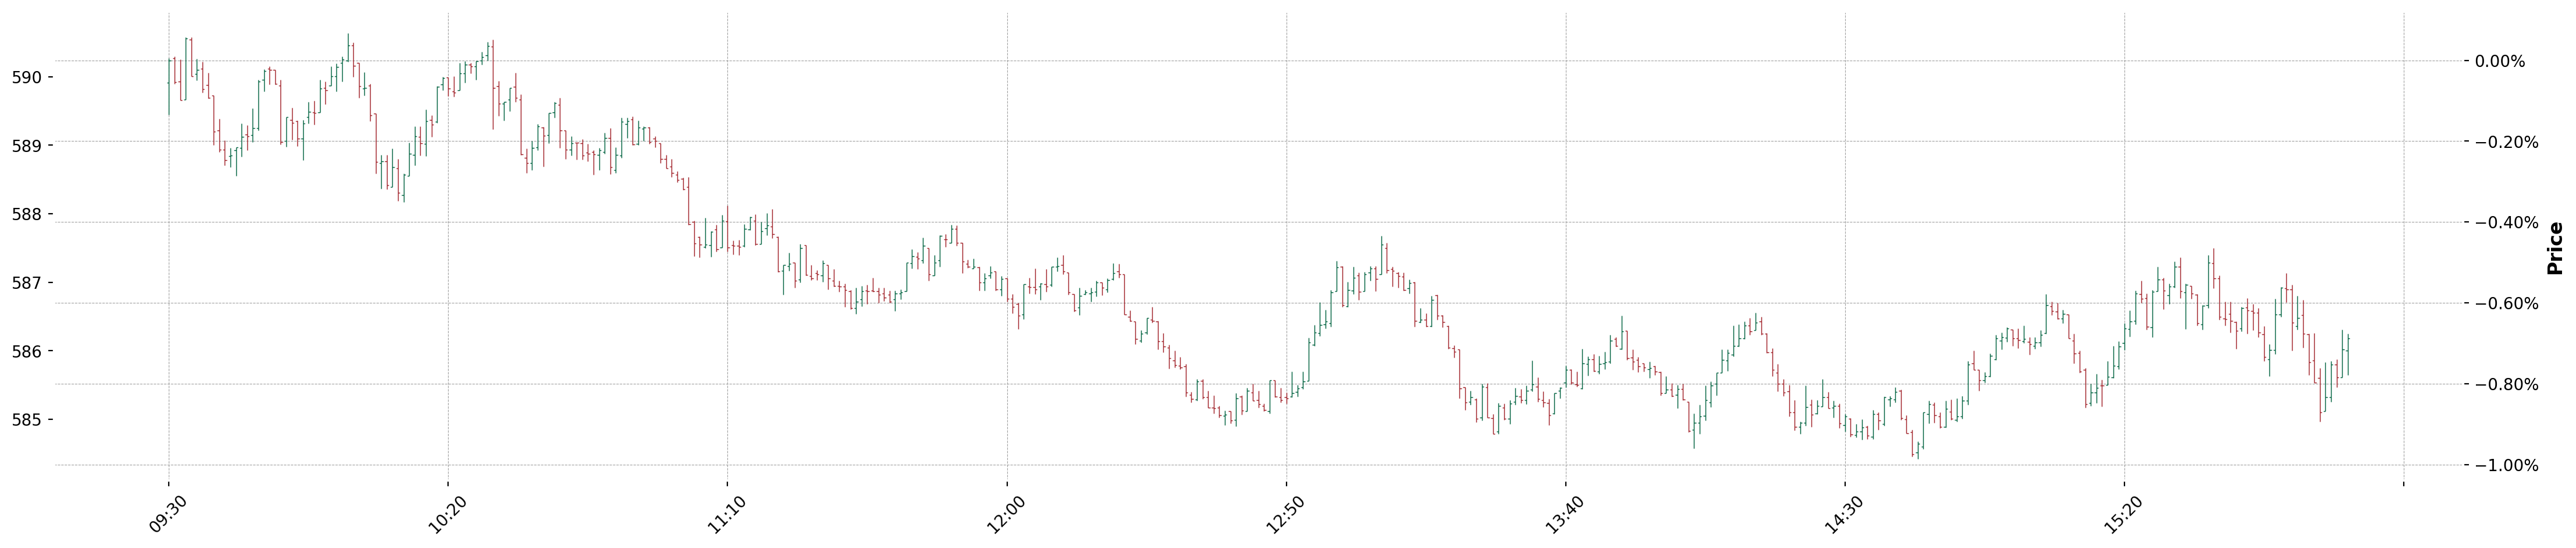

In [21]:
mpf.original_flavor = True
df=bars_df[m1].set_index('date').loc[:, ['open', 'high', 'low', 'close', 'volume']]
base = df['close'].iloc[0]
df[['open', 'high', 'low', 'close']] = df[['open', 'high', 'low', 'close']].apply(lambda x: (x / base) - 1)
df['date'] = df.index

ref = base
def price2pct(px):
    return (px - ref) / ref
def pct2price(pct):
    return pct * ref + ref
fig, axs = mpf.plot(df, style='charles', figratio=(5,1), returnfig=True)
# axs[0].set_facecolor('#4C4C4C')
secax = axs[0].secondary_yaxis('left', functions=(pct2price, price2pct))
axs[0].yaxis.set_major_locator(ticker.MultipleLocator(0.01))
axs[0].yaxis.set_major_locator(ticker.MultipleLocator(0.002))
axs[0].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=2))
# axs[0].xaxis.set_major_locator(ticker.MultipleLocator(10))
plt.show()

In [22]:
def extract_field_as_array(group, field_name):
    return np.array([getattr(item, field_name) for item in group])

# # Example usage
# a_arr = extract_field_as_array(group, 'a')
# b_arr = extract_field_as_array(group, 'b')
# c_arr = extract_field_as_array(group, 'c')

# print("a_arr:", a_arr)
# print("b_arr:", b_arr)
# print("c_arr:", c_arr)


In [23]:
N = 2000  # Set the maximum number of iterations

for i, group in enumerate(pairwise(bars)):
    if i >= N:
        break
    # print(f"{group}")
    close_open_arr = np.log(group[1].open / group[0].close)
    print(f"{close_open_arr:.3%}")
    # high_arr = extract_field_as_array(group, 'high')
    # low_arr = extract_field_as_array(group, 'low')
    # close_arr = extract_field_as_array(group, 'close')
    # open_arr = extract_field_as_array(group, 'open')
    # gk = garman_klass_volatility(open_arr, high_arr, low_arr, close_arr, len(group))
    # lnhl = np.log(high_arr / low_arr)
    # print(f"{group[-1].date} gk {gk:.3%}"
    #       f" rs {rogers_satchell_volatility(open_arr, high_arr, low_arr, close_arr, len(group)):.3%}"
    #       f" pk {parkinson_volatility(high_arr, low_arr, len(group)):.3%}"
    #       f" hml {lnhl[-1]:.3%} {lnhl[-1]/gk:.1f}"
    # )


TypeError: 'NoneType' object is not iterable

To request hourly data of the last 60 trading days:

In [ ]:
def get_bars(contract, durationStr='1 D', size='1 min', endDateTime='', rth=True):
    bars = ib.reqHistoricalData(
        contract,
        endDateTime=endDateTime,
        durationStr=durationStr,
        barSizeSetting=size,
        whatToShow='TRADES',
        useRTH=rth,
        formatDate=1)
    return bars # util.df(bars)

In [ ]:
dur = '30 D'
data = dict()
endDateTime = ''

In [ ]:
# bars = get_bars(spy, dur, '1 hour', endDateTime)

In [26]:
def load_data(sym, file_pattern='*_1m_*.csv', data_dir='.'):
    p = pathlib.Path(data_dir)
    files = list(p.glob(file_pattern))
    print(files)
    df = pd.read_csv(files[0], parse_dates=['date'])
    # df.index = pd.to_datetime(df['date'])
    # df = df.drop(columns=['date'])
    return df
df_spy = load_data('SPY', 'SPY_1m_241130*.csv')

[WindowsPath('SPY_1m_241130_212102.csv')]


In [ ]:
def df_to_csv(df, sym):
    filename = f'{sym}_1m_{datetime.datetime.now():%y%m%d_%H%M%S}.csv'
    df.to_csv(filename, index=False)
    print(f'{filename} saved')

In [ ]:
# df_to_csv(data['AMD'], 'AMD')
# df_to_csv(data['TLT'], 'TLT')
# df_to_csv(data['LQD'], 'LQD')
# df_to_csv(data['VOO'], 'VOO')
# df_to_csv(data['PLTR'], 'PLTR')
# df_to_csv(data['ARKK'], 'ARKK')
# df_to_csv(data['MSTR'], 'MSTR')
# df_to_csv(data['COIN'], 'COIN')
# df_to_csv(data['IBIT'], 'IBIT')
# df_to_csv(data['GBTC'], 'GBTC')
# df_to_csv(data['WMT'], 'WMT')

In [ ]:
def df_add_high_minus_low(df):
    df['high_minus_low'] = df['high'] - df['low']
    df['hml_log'] = np.log(df['high'] / df['low'])
    return df

In [ ]:
df_add_high_minus_low(data['AMD'])
df_add_high_minus_low(data['TLT'])
df_add_high_minus_low(data['LQD'])
df_add_high_minus_low(data['VOO'])
df_add_high_minus_low(data['PLTR'])
df_add_high_minus_low(data['ARKK'])
df_add_high_minus_low(data['MSTR'])
df_add_high_minus_low(data['COIN'])
df_add_high_minus_low(data['IBIT'])
df_add_high_minus_low(data['GBTC'])
df_add_high_minus_low(data['WMT']);

In [ ]:
df_add_high_minus_low(data['TSLA'])

In [27]:
df_spy['hml_log'] = np.log(df_spy['high']/df_spy['low'])


In [ ]:
def plot_hml(df, sym):
    fig, ax = plt.subplots(figsize=(12, 4))
    # ax.plot(df.index, df['hml_log'], label='log(High/Low)')
    df.plot(y='hml_log', kind='hist', bins=50, title=sym, range=(0, 0.0020), ax=ax)
    ax.set_title(f'{sym} High Minus Low')
    ax.legend()
    ax.grid(True)
    plt.show()

In [ ]:
plot_hml(data['AMD'], 'AMD')
plot_hml(data['TLT'], 'TLT')
plot_hml(data['LQD'], 'LQD')
plot_hml(data['VOO'], 'VOO')
plot_hml(data['PLTR'], 'PLTR')
plot_hml(data['ARKK'], 'ARKK')
plot_hml(data['MSTR'], 'MSTR')
plot_hml(data['COIN'], 'COIN')
plot_hml(data['IBIT'], 'IBIT')
plot_hml(data['GBTC'], 'GBTC')
plot_hml(data['WMT'], 'WMT')


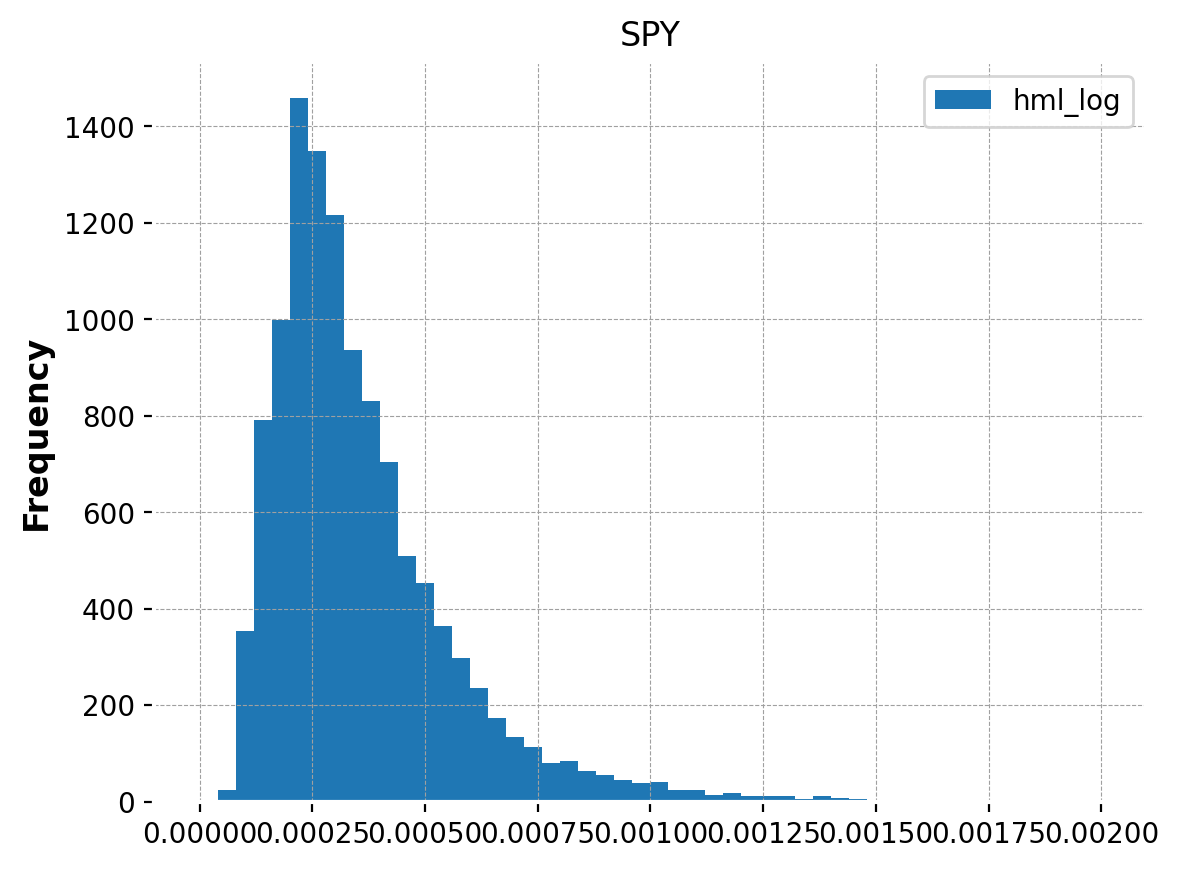

In [28]:
df_spy.plot(y='hml_log', kind='hist', bins=50, title='SPY', range=(0, 0.0020))
plt.show()


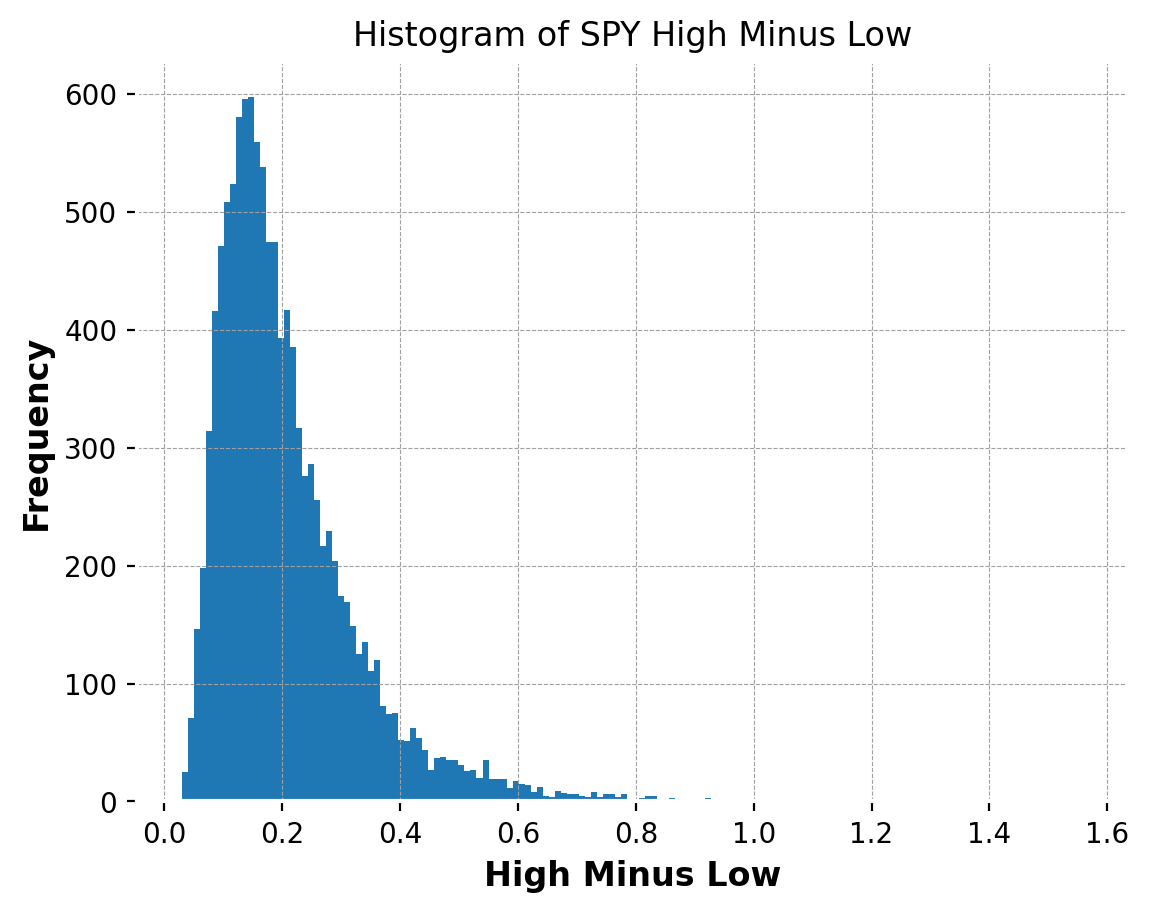

In [29]:
df_spy['high_minus_low'] = df_spy['high'] - df_spy['low']
df_spy['high_minus_low'].plot(kind='hist', bins=150, title='Histogram of SPY High Minus Low')
plt.xlabel('High Minus Low')
plt.ylabel('Frequency')
plt.show()

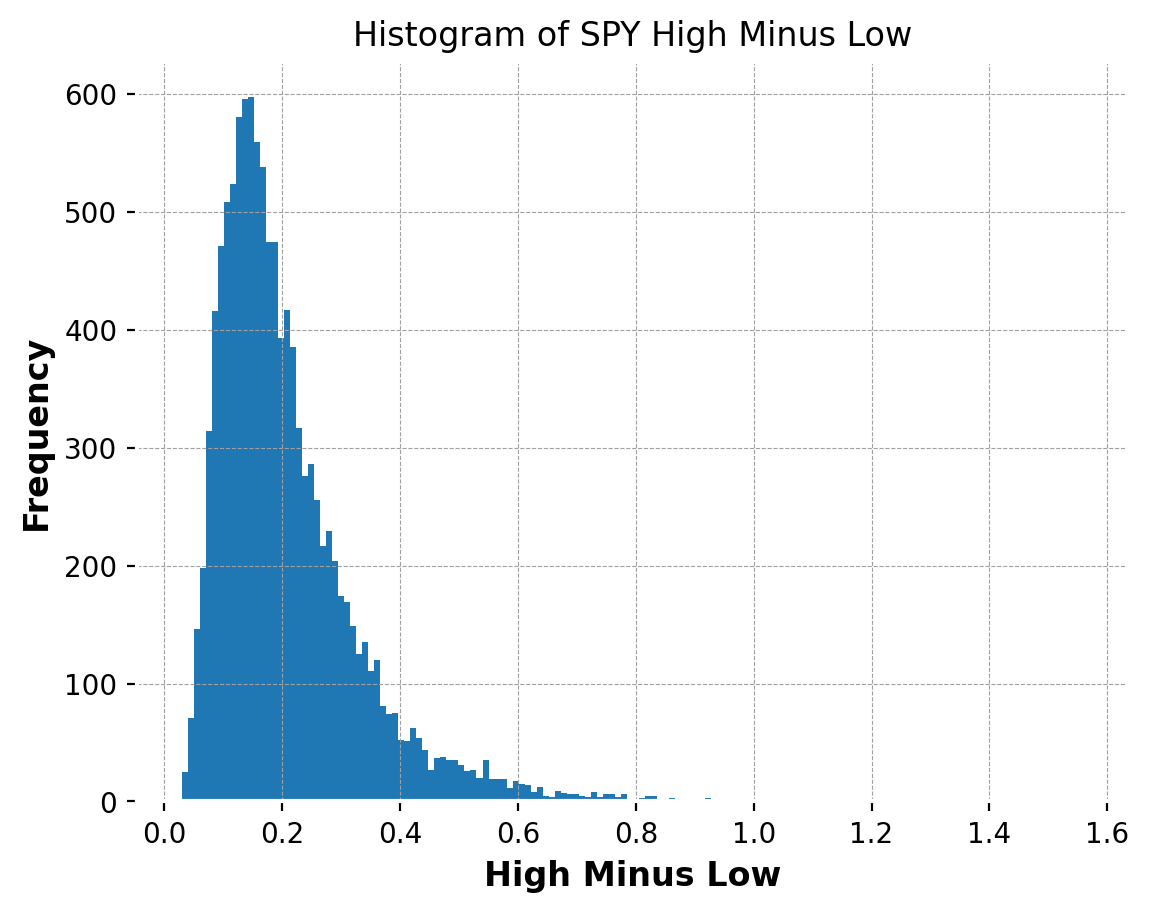

In [30]:
df_spy['high_minus_low'].plot(kind='hist', bins=150, title='Histogram of SPY High Minus Low')
plt.xlabel('High Minus Low')
plt.ylabel('Frequency')
plt.show()

In [ ]:
df_qqq['high_minus_low'].plot(kind='hist', bins=160, title='Histogram of QQQ High Minus Low')
plt.xlabel('High Minus Low')
plt.ylabel('Frequency')
plt.show()

In [ ]:
df_iwm['high_minus_low'].plot(kind='hist', bins=220, title='Histogram of IWM High Minus Low')
plt.xlabel('High Minus Low')
plt.ylabel('Frequency')
plt.show()


(1000, 11520)
(1000,)
99.0% confidence interval: [0.20770366753472297, 0.21358944878472308]


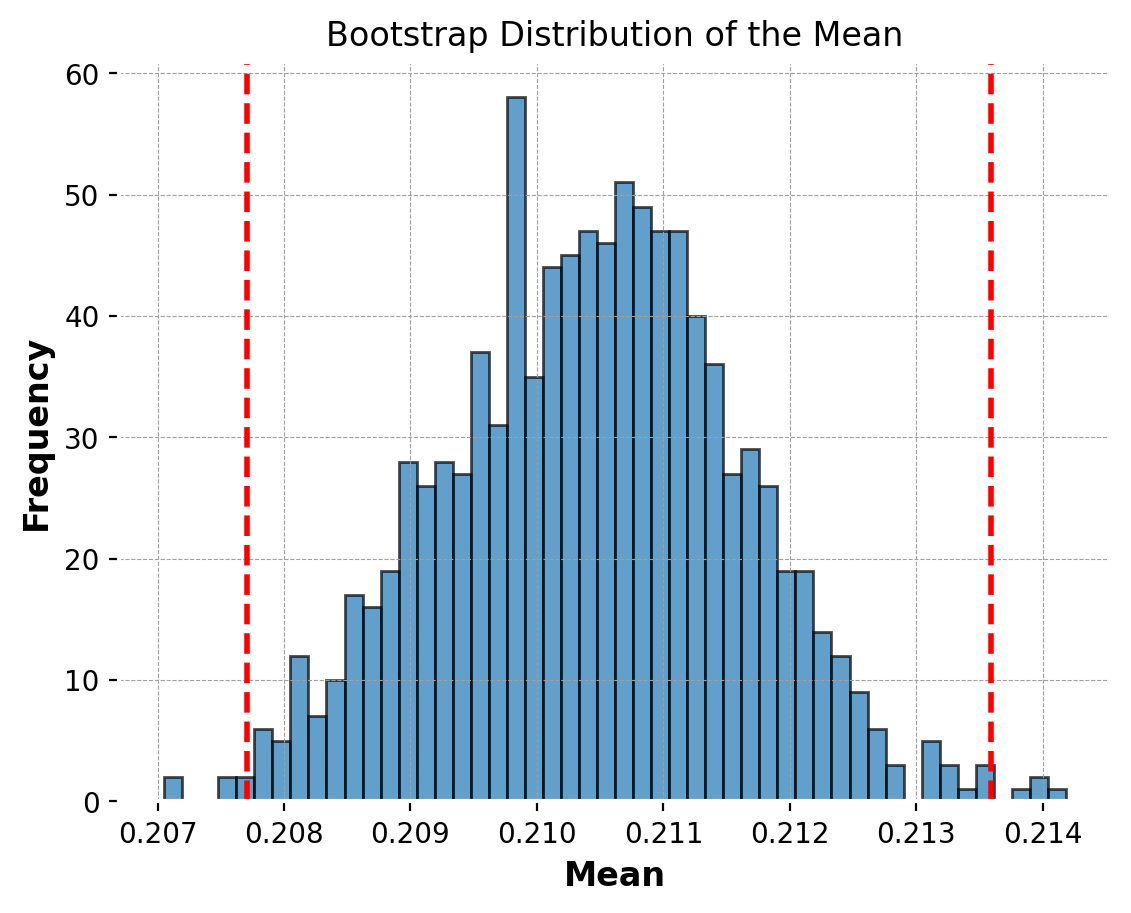

In [31]:
def bootstrap_resample(data, n_resamples=1000):
    resamples = np.random.choice(data, size=(n_resamples, len(data)), replace=True)
    return resamples
n_resamples = 1000
resamples = bootstrap_resample(df_spy['high_minus_low'].to_numpy(), n_resamples)
print(resamples.shape)
bootstrap_means = np.mean(resamples, axis=1)
print(bootstrap_means.shape)
confidence_level = 0.99
lower_bound = np.percentile(bootstrap_means, (1 - confidence_level) / 2 * 100)
upper_bound = np.percentile(bootstrap_means, (1 + confidence_level) / 2 * 100)
print(f"{confidence_level*100}% confidence interval: [{lower_bound}, {upper_bound}]")

plt.hist(bootstrap_means, bins=50, edgecolor='k', alpha=0.7)
plt.axvline(lower_bound, color='r', linestyle='--')
plt.axvline(upper_bound, color='r', linestyle='--')
plt.title('Bootstrap Distribution of the Mean')
plt.xlabel('Mean')
plt.ylabel('Frequency')
plt.show()


In [ ]:
from scipy.stats import bootstrap


In [ ]:
# Convert each timezone-aware datetime to naive datetime while preserving local time
df_spy['date'] = df_spy['date'].apply(lambda x: x.tz_localize(None))

In [ ]:
m1 = df_spy['date'].dt.time >= datetime.time(9, 35)
m2 = df_spy['date'].dt.time <= datetime.time(16, 0)

mask = df_spy.groupby(df_spy['date'].dt.date).apply(lambda x: x.iloc[5:-5]).reset_index(drop=True).index
df_spy = df_spy.loc[mask]


In [ ]:
df_spy[['open', 'high', 'low', 'close']].head().to_numpy()

In [ ]:
import numpy as np
from scipy.stats import bootstrap

# Your OHLC data
data = np.array([
    [584.03, 584.22, 582.99, 583.47],
    [583.47, 583.52, 583.24, 583.25],
    [583.22, 583.34, 583.06, 583.06],
    [583.1 , 583.18, 582.99, 583.07],
    [583.07, 583.07, 582.59, 582.62]
])
data = df_spy[['open', 'high', 'low', 'close']].to_numpy()

# Function to calculate volatility (e.g., using Parkinson estimator)
def parkinson_volatility(data):
    high = data[:, 1]
    low = data[:, 2]
    n = len(data)
    return np.sqrt(1 / (4 * np.log(2)) * np.sum(np.log(high / low)**2) / n)

# parkinson_volatility(data) * np.sqrt(252 * 1440)
# # Prepare data for bootstrapping
# data_for_bootstrap = (data,)

# # Perform bootstrap
# bootstrap_results = bootstrap(data_for_bootstrap, parkinson_volatility, confidence_level=0.95, 
#                                 random_state=1, method='percentile')

# # Extract confidence interval
# ci_low, ci_high = bootstrap_results.confidence_interval

# print(f"95% Confidence Interval for Parkinson Volatility: [{ci_low:.6f}, {ci_high:.6f}]")
# Calculate bootstrap confidence interval for Parkinson volatility
n_resamples = 1000
resamples = np.random.choice(data[:, 1] / data[:, 2], size=(n_resamples, len(data)), replace=True)
bootstrap_vols = np.array([parkinson_volatility(np.column_stack((data[:, 0], resample, data[:, 2], data[:, 3]))) for resample in resamples])

# Calculate confidence interval
ci_low = np.percentile(bootstrap_vols, (1 - confidence_level) / 2 * 100)
ci_high = np.percentile(bootstrap_vols, (1 + confidence_level) / 2 * 100)

print(f"95% Confidence Interval for Parkinson Volatility (manual bootstrap): [{ci_low:.6f}, {ci_high:.6f}]")

In [ ]:
import numpy as np
from scipy.stats import bootstrap

# Your OHLC data
data = np.array([
    [584.03, 584.22, 582.99, 583.47],
    [583.47, 583.52, 583.24, 583.25],
    [583.22, 583.34, 583.06, 583.06],
    [583.1 , 583.18, 582.99, 583.07],
    [583.07, 583.07, 582.59, 582.62]
])
data = df_spy[['open', 'high', 'low', 'close']].iloc[3:5].to_numpy()

# Function to calculate volatility (e.g., using Parkinson estimator)
def parkinson_volatility(high, low):
    n = len(high)
    return np.sqrt(1 / (4 * np.log(2)) * np.sum(np.log(high / low)**2) / n)

def annualized_volatility(high, low):
    return parkinson_volatility(high, low) * np.sqrt(252 * 1440)

# Calculate Parkinson volatility
volatility = parkinson_volatility(data[:, 1], data[:, 2]) * np.sqrt(252 * 1440)
print(f"Parkinson Volatility: {volatility} {annualized_volatility(data[:, 1], data[:, 2])}")

# # Prepare data for bootstrapping
# data_for_bootstrap = (data[:, 1], data[:, 2])

# # Perform bootstrap
# bootstrap_results = bootstrap(data_for_bootstrap, annualized_volatility, confidence_level=0.95, 
#                               random_state=1, method='percentile')

# # Extract confidence interval
# ci_low, ci_high = bootstrap_results.confidence_interval

# print(f"95% Confidence Interval: [{ci_low:.6f}, {ci_high:.6f}]")

In [ ]:
import numpy as np

def yang_zhang_volatility_simple(open_prices, high_prices, low_prices, close_prices, trading_periods=252):
    """
    Calculate Yang-Zhang volatility without rolling window.
    
    Parameters:
    - open_prices, high_prices, low_prices, close_prices: numpy arrays of price data
    - trading_periods: number of trading periods in a year (default 252)
    
    Returns:
    - Yang-Zhang volatility estimate (single value)
    """
    
    # Ensure inputs are numpy arrays
    open_prices = np.array(open_prices)
    high_prices = np.array(high_prices)
    low_prices = np.array(low_prices)
    close_prices = np.array(close_prices)
    
    n = len(open_prices)
    
    # Calculate log returns
    log_ho = np.log(high_prices / open_prices)
    log_lo = np.log(low_prices / open_prices)
    log_co = np.log(close_prices / open_prices)
    
    log_oc = np.log(open_prices[1:] / close_prices[:-1])
    log_cc = np.log(close_prices[1:] / close_prices[:-1])
    
    # Calculate components
    rs = log_ho[1:] * (log_ho[1:] - log_co[1:]) + log_lo[1:] * (log_lo[1:] - log_co[1:])
    close_vol = np.sum(log_cc**2) / (n - 2)
    open_vol = np.sum(log_oc**2) / (n - 1)
    window_rs = np.sum(rs) / (n - 1)
    
    # Combine components
    k = 0.34 / (1.34 + (n + 1) / (n - 1))
    yz_vol = np.sqrt(open_vol + k * close_vol + (1 - k) * window_rs)
    
    # Annualize
    return yz_vol * np.sqrt(trading_periods)

# Example usage with your data:
data = np.array([
    [584.03, 584.22, 582.99, 583.47],
    [583.47, 583.52, 583.24, 583.25],
    [583.22, 583.34, 583.06, 583.06],
    [583.1 , 583.18, 582.99, 583.07],
    [583.07, 583.07, 582.59, 582.62]
])

open_prices = data[:, 0]
high_prices = data[:, 1]
low_prices = data[:, 2]
close_prices = data[:, 3]

yz_vol = yang_zhang_volatility_simple(open_prices, high_prices, low_prices, close_prices) * np.sqrt(1440)
print(f"Yang-Zhang Volatility (annualized): {yz_vol:.6f}")

In [ ]:
import numpy as np

# Sample data
data = np.array([
    [584.03, 584.22, 582.99, 583.47],
    [583.47, 583.52, 583.24, 583.25],
    [583.22, 583.34, 583.06, 583.06],
    [583.1 , 583.18, 582.99, 583.07],
    [583.07, 583.07, 582.59, 582.62]
])
# data = df_spy[['open', 'high', 'low', 'close']].to_numpy()

# Extract OHLC data
open_prices = data[:, 0]
high_prices = data[:, 1]
low_prices = data[:, 2]
close_prices = data[:, 3]

# Number of intervals
n = len(data)

def parkinson_volatility(high, low, n):
    return np.sqrt(1 / (4 * np.log(2)) * np.sum(np.log(high / low)**2) / n)

def pv(high, low, n):
    # # Sample high and low prices
    # high_prices = np.array([105, 107, 106, 108, 109])
    # low_prices = np.array([100, 102, 101, 103, 104])

    # Calculate the logarithmic ranges
    log_ranges = np.log(high / low)
    # Sum of squared logarithmic ranges
    sum_squared_log_ranges = np.sum(log_ranges ** 2)
    # Number of intervals
    N = len(high)
    # Calculate Parkinson's volatility
    parkinson_volatility = np.sqrt(sum_squared_log_ranges / (4 * N * np.log(2)))
    return parkinson_volatility
    # print(f"Parkinson's Volatility: {parkinson_volatility}")

def garman_klass_volatility(open_, high, low, close, n):
    return np.sqrt(np.sum(0.5 * np.log(high / low)**2 - (2*np.log(2)-1) * np.log(close / open_)**2) / n)

def rogers_satchell_volatility(open_, high, low, close, n):
    return np.sqrt(np.sum((np.log(high / open_) * np.log(high / close) + np.log(low / open_) * np.log(low / close)) / n))

# def yang_zhang_volatility(open_, high, low, close, n):
#     return np.sqrt(0.511 * np.log(high / low)**2 - 0.019 * np.log(close / open_)**2 + 0.386 * np.log(close / open_) * np.log(high / low))

def yang_zhang_volatility(open_prices, high_prices, low_prices, close_prices):
    # Calculate log returns
    log_open_close = np.log(close_prices / open_prices)
    log_open_open = np.log(open_prices[1:] / open_prices[:-1])
    log_high_low = np.log(high_prices / low_prices)
    
    # Calculate the mean of log returns
    mean_log_open_close = np.mean(log_open_close)
    mean_log_open_open = np.mean(log_open_open)
    
    # Calculate the variances
    n = len(close_prices)
    k = 0.34 / (1.34 + (n + 1) / (n - 1))
    
    sigma_open_close = np.sum((log_open_close - mean_log_open_close) ** 2) / (n - 1)
    sigma_open_open = np.sum((log_open_open - mean_log_open_open) ** 2) / (n - 1)
    sigma_high_low = np.sum(log_high_low ** 2) / (n - 1)
    
    # Calculate Yang-Zhang volatility
    yz_volatility = np.sqrt(sigma_open_close + k * sigma_open_open + (1 - k) * sigma_high_low)
    
    return yz_volatility

# Calculate volatilities
parkinson_vol = parkinson_volatility(high_prices, low_prices, n)
garman_klass_vol = garman_klass_volatility(open_prices, high_prices, low_prices, close_prices, n)
rogers_satchell_vol = rogers_satchell_volatility(open_prices, high_prices, low_prices, close_prices, n)
yang_zhang_vol = yang_zhang_volatility(open_prices, high_prices, low_prices, close_prices)

# Annualize volatilities (assuming 252 trading days and 1440 minutes per day)
annualization_factor = np.sqrt(252 * 1440)
parkinson_vol_annual = parkinson_vol * annualization_factor
garman_klass_vol_annual = garman_klass_vol * annualization_factor
rogers_satchell_vol_annual = rogers_satchell_vol * annualization_factor
yang_zhang_vol_annual = yang_zhang_vol * annualization_factor

print(f"Parkinson Volatility (annualized): {parkinson_vol_annual:.4f} {pv(high_prices, low_prices, n)*annualization_factor:.4f}")
print(f"Garman-Klass Volatility (annualized): {garman_klass_vol_annual:.4f}")
print(f"Rogers-Satchell Volatility (annualized): {rogers_satchell_vol_annual:.4f}")
# Calculate Yang-Zhang volatility
yz_volatility = yang_zhang_volatility(open_prices, high_prices, low_prices, close_prices) * annualization_factor
print(f"Yang-Zhang Volatility: {yang_zhang_volatility_simple(open_prices, high_prices, low_prices, close_prices, trading_periods=252*1440)}")

# print(f"Yang-Zhang Volatility: {yang_zhang_vol_annual}")

In [ ]:
import numpy as np

def parkinson_volatility(high, low, n):
    return np.sqrt(1 / (4 * np.log(2)) * np.sum(np.log(high / low)**2) / n)

def garman_klass_volatility(open, high, low, close, n):
    return np.sqrt(np.sum(0.5 * np.log(high / low)**2 - (2*np.log(2)-1) * np.log(close / open)**2) / n)

def rogers_satchell_volatility(open, high, low, close, n):
    return np.sqrt(np.sum((np.log(high / open) * np.log(high / close) + np.log(low / open) * np.log(low / close)) / n))

To estimate asset volatility from OHLC (Open, High, Low, Close) data with 1-minute intervals, you can use several range-based volatility estimators. These methods are more efficient than traditional close-to-close estimators because they incorporate more price information. Here are some popular approaches:

## Parkinson Estimator

This method uses only the high and low prices and is up to 5.2 times more efficient than close-to-close estimates. The formula is:

$$ \sigma_P = \sqrt{\frac{1}{4\ln(2)} \cdot \frac{1}{n} \sum_{i=1}^n (\ln(H_i) - \ln(L_i))^2} $$

Where $H_i$ and $L_i$ are the high and low prices for each interval, and n is the number of intervals.

## Garman-Klass Estimator

This method uses all OHLC prices and is up to 7.4 times more efficient than close-to-close estimates. The formula is:

$$ \sigma_{GK} = \sqrt{\frac{1}{n} \sum_{i=1}^n (0.5(\ln(H_i) - \ln(L_i))^2 - (2\ln(2)-1)(\ln(C_i) - \ln(O_i))^2)} $$

Where $O_i$ and $C_i$ are the open and close prices for each interval.

## Rogers-Satchell Estimator

This method handles non-zero drifts and uses all OHLC prices. The formula is:

$$ \sigma_{RS} = \sqrt{\frac{1}{n} \sum_{i=1}^n (\ln(H_i) - \ln(O_i))(\ln(H_i) - \ln(C_i)) + (\ln(L_i) - \ln(O_i))(\ln(L_i) - \ln(C_i))} $$

## Implementation in Python

```python
import numpy as np

def parkinson_volatility(high, low, n):
    return np.sqrt(1 / (4 * np.log(2)) * np.sum(np.log(high / low)**2) / n)

def garman_klass_volatility(open, high, low, close, n):
    return np.sqrt(np.sum(0.5 * np.log(high / low)**2 - (2*np.log(2)-1) * np.log(close / open)**2) / n)

def rogers_satchell_volatility(open, high, low, close, n):
    return np.sqrt(np.sum((np.log(high / open) * np.log(high / close) + np.log(low / open) * np.log(low / close)) / n))

In [ ]:

# Calculate bootstrap confidence interval
confidence_level = 0.99
data = df_spy['high_minus_low'].to_numpy()
res = bootstrap((data,), np.mean, confidence_level=confidence_level, n_resamples=1000, method='percentile')
print(f"{confidence_level*100}% confidence interval: [{res.confidence_interval.low}, {res.confidence_interval.high}]")

m1 = df_spy['date'].dt.time >= datetime.time(9, 35)
m2 = df_spy['date'].dt.time <= datetime.time(15, 55)
data = df_spy.loc[m1 & m2, 'high_minus_low'].to_numpy()
res = bootstrap((data,), np.mean, confidence_level=confidence_level, n_resamples=1000, method='percentile')
print(f"{confidence_level*100}% confidence interval: [{res.confidence_interval.low}, {res.confidence_interval.high}]")

data = df_spy.groupby(df_spy['date'].dt.date).apply(lambda x: x.iloc[5:-5]).reset_index(drop=True)['high_minus_low'].to_numpy()
res = bootstrap((data,), np.mean, confidence_level=confidence_level, n_resamples=1000, method='percentile')
print(f"{confidence_level*100}% confidence interval: [{res.confidence_interval.low}, {res.confidence_interval.high}]")


In [ ]:
print("Descriptive statistics for SPY high_minus_low:")
print(f"Median: {df_spy['high_minus_low'].median()}")
print(df_spy['high_minus_low'].describe())


In [ ]:
print("Descriptive statistics for SPY hml_log:")
print(f"Median: {df_spy['hml_log'].median()}")
print(df_spy['hml_log'].describe())


In [ ]:

print("\nDescriptive statistics for QQQ high_minus_low:")
print(f"Median: {df_qqq['high_minus_low'].median()}")
print(df_qqq['high_minus_low'].describe())

print("\nDescriptive statistics for IWM high_minus_low:")
print(f"Median: {df_iwm['high_minus_low'].median()}")
print(df_iwm['high_minus_low'].describe())


In [ ]:
print(df_tsla['hml_log'].describe())

In [ ]:
for sym, df in data.items():
    print(f"\nDescriptive statistics for {sym} hml_log:")
    print(f"Median: {df['hml_log'].median()}")
    print(df['hml_log'].describe())

In [ ]:
print('SPY\n', df_spy['hml_log'].describe())
print('QQQ\n', df_qqq['hml_log'].describe())
print('IWM\n', df_iwm['hml_log'].describe())
print('DIA\n', df_dia['hml_log'].describe())
print('TSLA\n', df_tsla['hml_log'].describe())
print('MSFT\n', df_msft['hml_log'].describe())
print('NVDA\n', df_nvda['hml_log'].describe())
print('AAPL\n', df_aapl['hml_log'].describe())
print('GOOG\n', df_goog['hml_log'].describe())
print('META\n', df_meta['hml_log'].describe())


In [ ]:
import io
buffer = io.StringIO()

In [ ]:
bars_df.info(buf=buffer, verbose=True, show_counts=True)

In [ ]:
print(buffer.getvalue())

In [ ]:
print(bars_df.describe().to_string())

In [ ]:
filename = f'NVDA_1m_{datetime.datetime.now():%y%m%d_%H%M%S}.csv'
bars_df.to_csv(filename, index=False)

In [ ]:
pd.options.display.float_format = '{:.4f}'.format

In [ ]:
X = bars_df.set_index('date').loc['2024-11-26 09:30:00':'2024-11-25 16:00:00',['average']].values

In [ ]:
from sklearn.neighbors import KernelDensity
import numpy as np
# X = np.array([[-1, -1], [-2, -1], [-3, -2], [1, 1], [2, 1], [3, 2]])
# X = bars_df[['close']].values


In [ ]:
N = 20
X = np.concatenate(
    (np.random.normal(0, 1, int(0.3 * N)), np.random.normal(5, 1, int(0.7 * N)))
)[:, np.newaxis]

In [ ]:
X_plot = np.linspace(595, 601, 1000)[:, np.newaxis]

In [ ]:
kde = KernelDensity(kernel='tophat', bandwidth=.05).fit(X)
log_dens = kde.score_samples(X_plot)
Y = np.exp(log_dens)

In [ ]:
plt.fill(X_plot[:, 0], Y)
plt.plot(X[:, 0], np.full(X.shape[0], -0.02), '+k')
plt.show()

In [ ]:
from typing import List, Tuple

In [ ]:
def mn_bars_red(bars: List[BarData], start: int, end: int, relax: bool=False, consecutive: bool=False) -> int:
    """
    start, end are negative list index
    count the number of consecutive red bars from start to end
    """
    # if len(bars) < abs(start) or len(bars) < abs(end):
    #     return False
    print(len(bars), start, end, sep=', ', end='; ')
    count = 0
    for bar in bars[start:end:-1]: # from the tail end
        if bar.close < bar.open:
            count += 1
        elif relax and bar.close == bar.open: # yellow bar ok if relax
            count += 1
        elif not relax and bar.close == bar.open: # yellow bar not ok if not relax
            break
        elif consecutive: # we're looking for consecutive red bars
            break
    return count

In [ ]:
for j in range(len(bars)):
    res = mn_bars_red(bars[max(0, j-23):j+1], -3, -23, relax=True, consecutive=True)
    # list1 = bars[0:j+1]
    # res = mn_bars_red(list1[-23:], -3, -23, relax=True, consecutive=True)
    if res >= 0:
        print(j, bars[j].date, res)

In [33]:
# fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the candlestick chart
# mpf.plot(bars_df.set_index('date').loc['2024-11-25 09:30:00':'2024-11-25 16:00:00',:], type='candle', style='charles', ax=ax1)

# Create a secondary y-axis
ax2 = axs[0].twinx()

# Calculate the percentage change
bars_df['pct_change'] = bars_df['close'].pct_change() * 100

# Plot the percentage change on the secondary y-axis
ax2.plot(bars_df['date'], bars_df['pct_change'], color='blue', alpha=0.3)
ax2.set_ylabel('Percentage Change (%)')

plt.show()

In [ ]:
plt.show()

In [34]:
import numpy as np
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt

# Generate sample data
# x = np.linspace(-10, 10, 100)
# y = np.sin(x) + np.random.normal(0, 0.2, x.shape)

# Apply Gaussian filters with different orders
y_smooth = gaussian_filter1d(y, sigma=2, order=0)
y_first_derivative = gaussian_filter1d(y, sigma=2, order=1)
y_second_derivative = gaussian_filter1d(y, sigma=2, order=2)

# Plot results
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(x, y, label='Original')
plt.plot(x, y_smooth, label='Smoothed (order=0)')
plt.legend()
plt.title('Gaussian Filter (order=0)')

plt.subplot(3, 1, 2)
plt.plot(x, y, label='Original')
plt.plot(x, y_first_derivative)
plt.title('First Derivative (order=1)')

plt.subplot(3, 1, 3)
plt.plot(x, y, label='Original')
plt.plot(x, y_second_derivative)
plt.title('Second Derivative (order=2)')

plt.tight_layout()
plt.show()

NameError: name 'y' is not defined

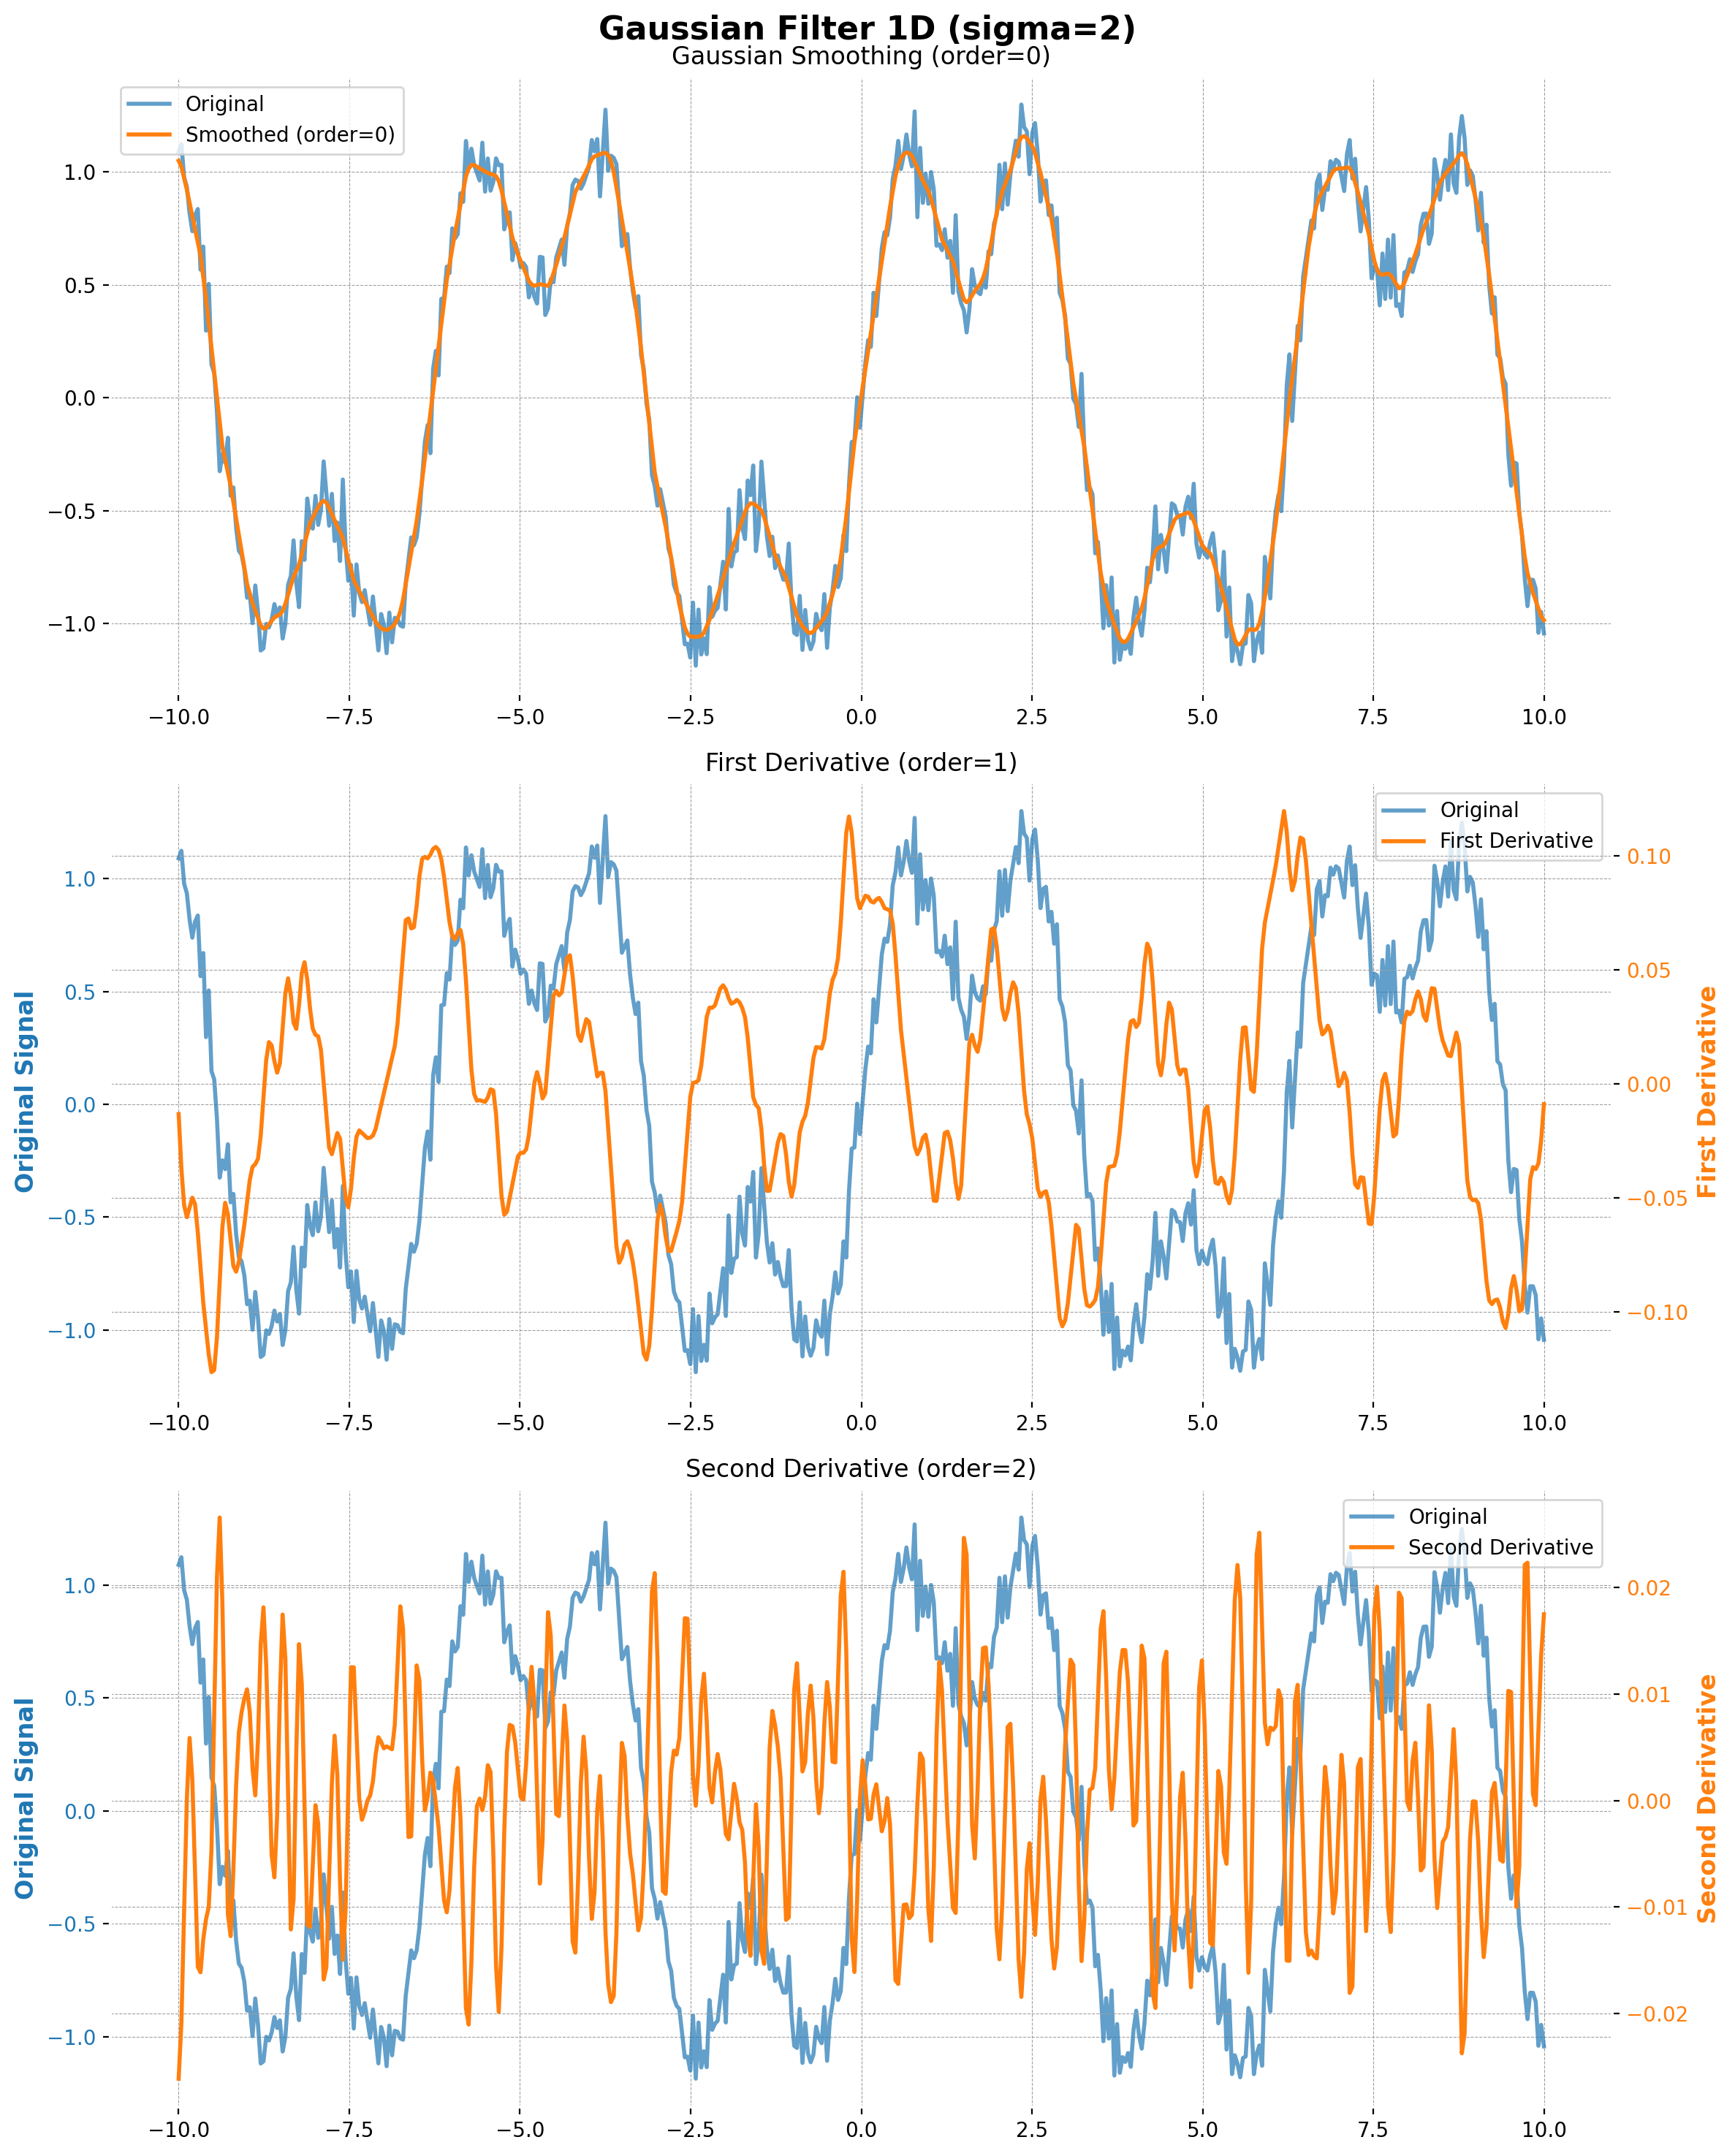

In [35]:
import numpy as np
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt

# Generate sample data
x = np.linspace(-10, 10, 500)
y = np.sin(x) + 0.5 * np.sin(3*x) + np.random.normal(0, 0.1, x.shape)

# Apply Gaussian filters with different orders
sigma = 2
y_smooth = gaussian_filter1d(y, sigma=sigma, order=0)
y_first_derivative = gaussian_filter1d(y, sigma=sigma, order=1)
y_second_derivative = gaussian_filter1d(y, sigma=sigma, order=2)

# Plot results
fig, axs = plt.subplots(3, 1, figsize=(12, 15))
fig.suptitle(f'Gaussian Filter 1D (sigma={sigma})', fontsize=16)

# Order 0
axs[0].plot(x, y, label='Original', alpha=0.7)
axs[0].plot(x, y_smooth, label='Smoothed (order=0)')
axs[0].legend()
axs[0].set_title('Gaussian Smoothing (order=0)')

# Order 1
ax1 = axs[1]
ax1.plot(x, y, label='Original', alpha=0.7)
ax1.set_ylabel('Original Signal', color='C0')
ax1.tick_params(axis='y', labelcolor='C0')

ax1_twin = ax1.twinx()
ax1_twin.plot(x, y_first_derivative, 'C1', label='First Derivative')
ax1_twin.set_ylabel('First Derivative', color='C1')
ax1_twin.tick_params(axis='y', labelcolor='C1')

ax1.set_title('First Derivative (order=1)')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# Order 2
ax2 = axs[2]
ax2.plot(x, y, label='Original', alpha=0.7)
ax2.set_ylabel('Original Signal', color='C0')
ax2.tick_params(axis='y', labelcolor='C0')

ax2_twin = ax2.twinx()
ax2_twin.plot(x, y_second_derivative, 'C1', label='Second Derivative')
ax2_twin.set_ylabel('Second Derivative', color='C1')
ax2_twin.tick_params(axis='y', labelcolor='C1')

ax2.set_title('Second Derivative (order=2)')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from scipy.stats import skew, kurtosis

class OnlineStats:
    def __init__(self, upper_bound):
        self.n = 0
        self.mean = 0.0
        self.M2 = 0.0
        self.upper_bound = upper_bound
        self.counts = np.zeros(upper_bound + 1, dtype=int)

    def update(self, x):
        self.n += 1
        delta = x - self.mean
        self.mean += delta / self.n
        delta2 = x - self.mean
        self.M2 += delta * delta2
        self.counts[x] += 1

    def variance(self):
        return self.M2 / self.n if self.n > 1 else 0.0

    def stddev(self):
        return np.sqrt(self.variance())

    def skewness(self):
        return skew(self.counts)

    def kurtosis(self):
        return kurtosis(self.counts)

    def mode(self):
        return np.argmax(self.counts)

    def quartiles(self):
        cumulative_counts = np.cumsum(self.counts)
        total = cumulative_counts[-1]
        return [np.searchsorted(cumulative_counts, total * q / 4) for q in range(1, 4)]

    def deciles(self):
        cumulative_counts = np.cumsum(self.counts)
        total = cumulative_counts[-1]
        return [np.searchsorted(cumulative_counts, total * d / 10) for d in range(1, 10)]

# Example usage
stats = OnlineStats(upper_bound=30)

# Simulate streaming data
data_stream = np.random.randint(0, 31, 100)  # Replace with actual sensor data

for data in data_stream:
    stats.update(data)

s = f'Mean: {stats.mean}'
print(f'Standard Deviation: {stats.stddev()}')
print(f'Skewness: {stats.skewness()}')
print(f'Kurtosis: {stats.kurtosis()}')
print(f'Mode: {stats.mode()}')
print(f'Quartiles: {stats.quartiles()}')
s = f'Deciles: {stats.deciles()}'


In [ ]:
stats.counts

In [ ]:
import numpy as np
from collections import deque
from scipy.stats import skew, kurtosis, mode

class OnlineStatsFloat:
    def __init__(self):
        self.n = 0
        self.mean = 0.0
        self.M2 = 0.0
        self.values = deque(maxlen=1000)  # Keep a limited history for mode, quartiles, and deciles

    def update(self, x):
        self.n += 1
        delta = x - self.mean
        self.mean += delta / self.n
        delta2 = x - self.mean
        self.M2 += delta * delta2
        self.values.append(x)

    def variance(self):
        return self.M2 / self.n if self.n > 1 else 0.0

    def stddev(self):
        return np.sqrt(self.variance())

    def skewness(self):
        return skew(self.values)

    def kurtosis(self):
        return kurtosis(self.values)

    def mode(self):
        return mode(self.values).mode[0]

    def quartiles(self):
        return np.percentile(self.values, [25, 50, 75])

    def deciles(self):
        return np.percentile(self.values, np.arange(10, 100, 10))

# Example usage
statsfloat = OnlineStatsFloat()

# Simulate streaming data
# data_stream_float = np.random.uniform(0, 30, 1000)  # Replace with actual sensor data

for data in data_stream:
    statsfloat.update(data)

print(f'Mean: {statsfloat.mean}')
s = f'Standard Deviation: {statsfloat.stddev()}'
s = f'Skewness: {statsfloat.skewness()}'
print(f'Kurtosis: {statsfloat.kurtosis()}')
print(f'Mode: {statsfloat.mode()}')
print(f'Quartiles: {statsfloat.quartiles()}')
print(f'Deciles: {statsfloat.deciles()}')


In [37]:
mode(np.asarray(statsfloat.values), keepdims=True).mode[0]

NameError: name 'mode' is not defined

In [38]:
m1 = bars_df['date'] >= pd.Timestamp('2024-11-08 9:30 -5:00')
x_dates = bars_df.loc[m1, 'date'] 
bars_df['date'][0].tz

datetime.timezone(datetime.timedelta(days=-1, seconds=68400))

In [39]:
# Define your vector and the pattern (kernel)
vector = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0])
pattern = np.array([5, 4, 3, 2, 1])

# Perform the convolution
convolution_result = np.convolve(vector, pattern[::-1], mode='valid')

# Normalize the convolution result
pattern_norm = np.linalg.norm(pattern)
normalized_result = convolution_result / pattern_norm

# Check for significant values in the result
print(convolution_result)
print(normalized_result)



[ 20  35  50  65  80  95 110 123 132 135 130 115 100  85  70  55  40]
[ 2.69679945  4.71939904  6.74199862  8.76459821 10.7871978  12.80979739
 14.83239697 16.58531662 17.79887637 18.20339629 17.52919642 15.50659684
 13.48399725 11.46139766  9.43879807  7.41619849  5.3935989 ]


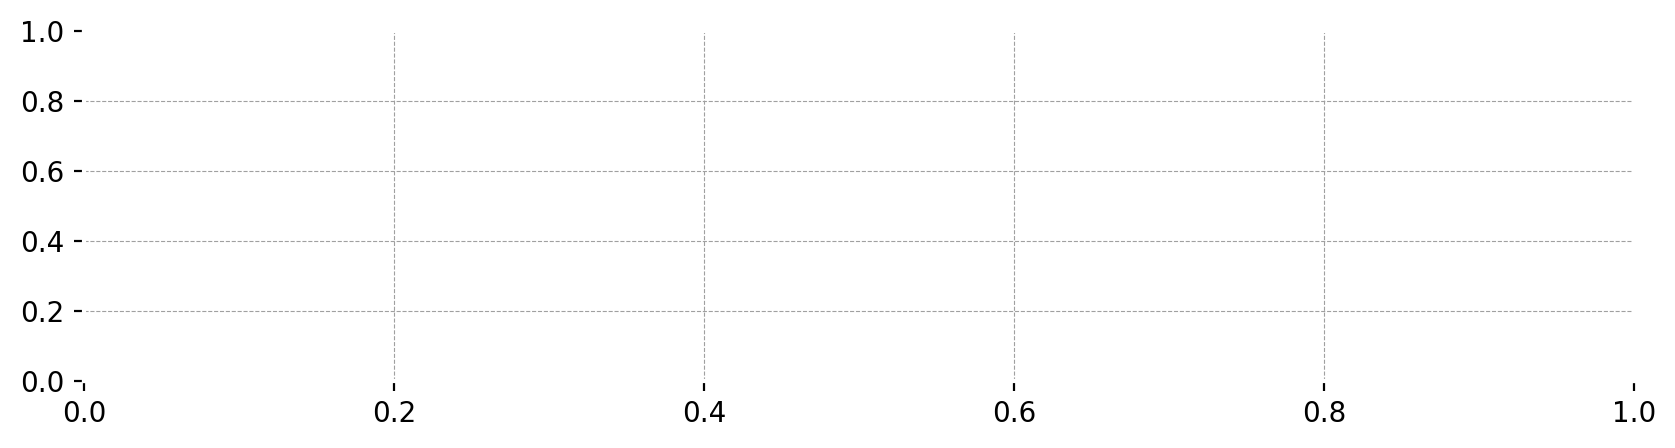

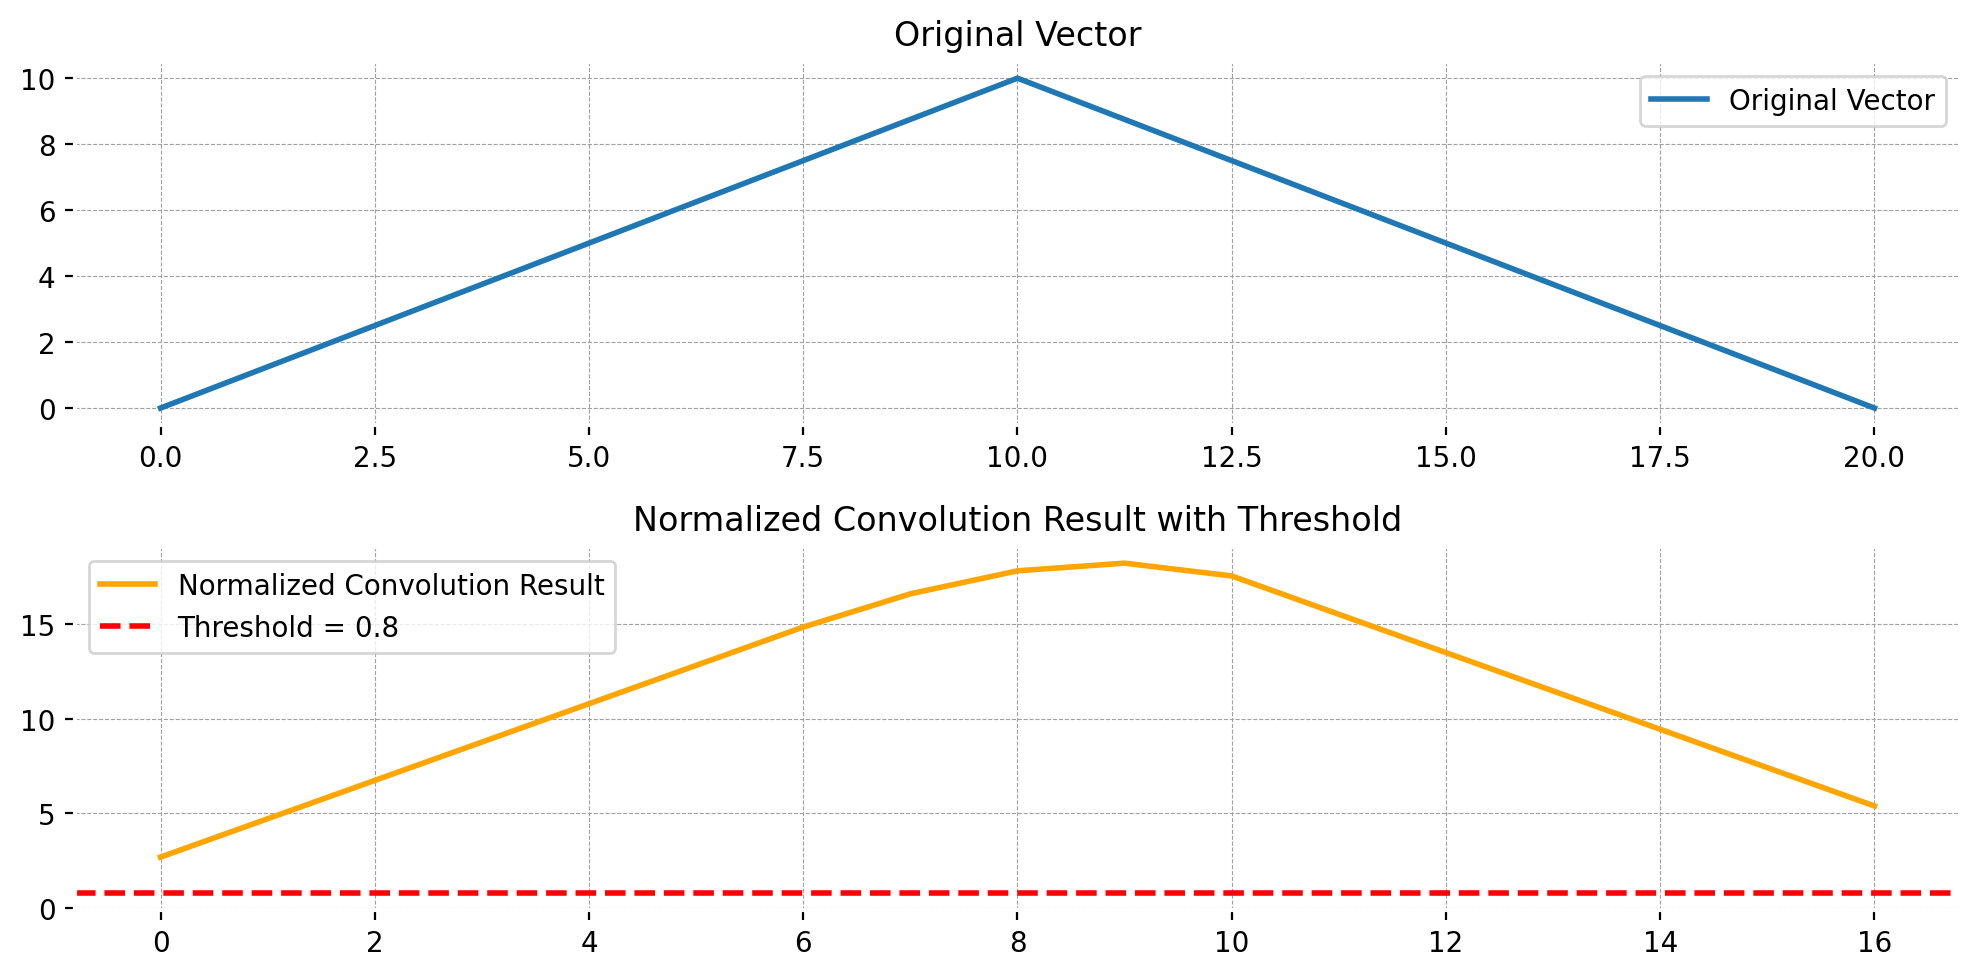

In [40]:
# Plot the original vector and the normalized convolution result
plt.figure(figsize=(10, 5))

plt.subplot(2, 1, 1)
plt.plot(vector, label='Original Vector')
plt.title('Original Vector')
plt.legend()

# Define a threshold for pattern detection
threshold = 0.8  # Adjust this value as needed

plt.subplot(2, 1, 2)
plt.plot(normalized_result, label='Normalized Convolution Result', color='orange')
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold = {threshold}')
plt.title('Normalized Convolution Result with Threshold')
plt.legend()

plt.tight_layout()
plt.show()

### Handling Noisy Data in Pattern Detection

Handling noisy data in pattern detection can be challenging, but there are several strategies you can use to improve the robustness of your convolution-based approach:

1. **Smoothing the Data**: Apply a smoothing filter, such as a moving average or Gaussian filter, to reduce noise before performing the convolution. This can help highlight the underlying patterns more clearly.

    ```python
    import numpy as np
    from scipy.ndimage import gaussian_filter1d

    # Example vector with noise
    vector = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]) + np.random.normal(0, 0.5, 10)
    
    # Apply Gaussian smoothing
    smoothed_vector = gaussian_filter1d(vector, sigma=1)
    ```

2. **Thresholding the Convolution Output**: After performing the convolution, apply a threshold to the output to identify significant matches. This can help filter out noise-induced false positives.

    ```python
    # Define the pattern and perform convolution
    pattern = np.array([1, 2, 3, 4, 5])
    convolution_result = np.convolve(smoothed_vector, pattern[::-1], mode='valid')
    
    # Apply a threshold
    threshold = np.max(convolution_result) * 0.8
    significant_matches = convolution_result > threshold
    ```

3. **Robust Pattern Matching**: Use more sophisticated pattern matching techniques that are less sensitive to noise, such as dynamic time warping (DTW) or cross-correlation.

    ```python
    from scipy.signal import correlate

    # Cross-correlation for pattern matching
    correlation_result = correlate(smoothed_vector, pattern, mode='valid')
    ```

4. **Machine Learning Approaches**: Train a machine learning model to recognize patterns in noisy data. Convolutional neural networks (CNNs) are particularly effective for this purpose. You can train a CNN to detect patterns in your data, even in the presence of noise.

    ```python
    # Example of a simple CNN model using Keras
    from keras.models import Sequential
    from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

    model = Sequential([
        Conv1D(32, kernel_size=5, activation='relu', input_shape=(vector_length, 1)),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(1, activation='sigmoid')
    ])
    ```

By combining these techniques, you can enhance your ability to detect patterns in noisy data. If you need more detailed guidance on any of these methods, feel free to ask!


Handling noisy data in pattern detection can be challenging, but there are several strategies you can use to improve the robustness of your convolution-based approach:

1. **Smoothing the Data**: Apply a smoothing filter, such as a moving average or Gaussian filter, to reduce noise before performing the convolution. This can help highlight the underlying patterns more clearly.

    ```python
    import numpy as np
    from scipy.ndimage import gaussian_filter1d

    # Example vector with noise
    vector = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]) + np.random.normal(0, 0.5, 10)
    
    # Apply Gaussian smoothing
    smoothed_vector = gaussian_filter1d(vector, sigma=1)
    ```

2. **Thresholding the Convolution Output**: After performing the convolution, apply a threshold to the output to identify significant matches. This can help filter out noise-induced false positives.

    ```python
    # Define the pattern and perform convolution
    pattern = np.array([1, 2, 3, 4, 5])
    convolution_result = np.convolve(smoothed_vector, pattern[::-1], mode='valid')
    
    # Apply a threshold
    threshold = np.max(convolution_result) * 0.8
    significant_matches = convolution_result > threshold
    ```

3. **Robust Pattern Matching**: Use more sophisticated pattern matching techniques that are less sensitive to noise, such as dynamic time warping (DTW) or cross-correlation.

    ```python
    from scipy.signal import correlate

    # Cross-correlation for pattern matching
    correlation_result = correlate(smoothed_vector, pattern, mode='valid')
    ```

4. **Machine Learning Approaches**: Train a machine learning model to recognize patterns in noisy data. Convolutional neural networks (CNNs) are particularly effective for this purpose. You can train a CNN to detect patterns in your data, even in the presence of noise¹².

    ```python
    # Example of a simple CNN model using Keras
    from keras.models import Sequential
    from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

    model = Sequential([
        Conv1D(32, kernel_size=5, activation='relu', input_shape=(vector_length, 1)),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(1, activation='sigmoid')
    ])
    ```

By combining these techniques, you can enhance your ability to detect patterns in noisy data. If you need more detailed guidance on any of these methods, feel free to ask!

Source: Conversation with Copilot, 11/9/2024
(1) [1406.2080] Training Convolutional Networks with Noisy Labels - arXiv.org. https://arxiv.org/abs/1406.2080.
(2) [1412.6596] Training Deep Neural Networks on Noisy Labels with .... https://arxiv.org/abs/1412.6596.
(3) An adaptive fully convolutional network for bearing fault diagnosis .... https://pubs.aip.org/aip/rsi/article/95/4/045113/3282508/An-adaptive-fully-convolutional-network-for.
(4) Uncertainty handling in convolutional neural networks. https://link.springer.com/article/10.1007/s00521-022-07313-2.
(5) Sparse Convolutional Networks for Surface Reconstruction from Noisy .... https://openaccess.thecvf.com/content/WACV2024/papers/Wang_Sparse_Convolutional_Networks_for_Surface_Reconstruction_From_Noisy_Point_Clouds_WACV_2024_paper.pdf.
(6) undefined. https://doi.org/10.48550/arXiv.1406.2080.
(7) undefined. https://doi.org/10.48550/arXiv.1412.6596.

Choosing an optimal threshold value for pattern detection can be approached in several ways. Here are some common methods:

1. **Manual Adjustment**: Start with an initial guess and adjust based on visual inspection of the results. This is straightforward but can be subjective and time-consuming.

2. **Statistical Methods**: Use statistical properties of the convolution output to set the threshold. For example, you could set the threshold to a certain number of standard deviations above the mean of the convolution output.

    ```python
    mean = np.mean(normalized_result)
    std_dev = np.std(normalized_result)
    threshold = mean + 2 * std_dev  # Adjust the multiplier as needed
    ```

3. **Otsu's Method**: This method automatically determines the optimal threshold by maximizing the between-class variance. It's commonly used in image processing but can be adapted for other types of data.

    ```python
    from skimage.filters import threshold_otsu

    threshold = threshold_otsu(normalized_result)
    ```

4. **Cross-Validation**: If you have labeled data, you can use cross-validation to find the threshold that maximizes the detection accuracy. This involves splitting your data into training and validation sets and testing different threshold values.

5. **Receiver Operating Characteristic (ROC) Curve**: Plot the ROC curve and choose the threshold that provides the best trade-off between true positive rate and false positive rate.

    ```python
    from sklearn.metrics import roc_curve

    # Assuming you have true labels and predicted scores
    fpr, tpr, thresholds = roc_curve(true_labels, normalized_result)
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]
    ```

6. **Iterative Methods**: Use iterative methods to refine the threshold. For example, you can start with an initial threshold and iteratively adjust it based on the results until it stabilizes.

    ```python
    def iterative_threshold(data, initial_threshold):
        threshold = initial_threshold
        while True:
            above_threshold = data[data > threshold]
            below_threshold = data[data <= threshold]
            new_threshold = (np.mean(above_threshold) + np.mean(below_threshold)) / 2
            if np.abs(new_threshold - threshold) < 1e-3:  # Convergence criterion
                break
            threshold = new_threshold
        return threshold

    threshold = iterative_threshold(normalized_result, initial_threshold=0.5)
    ```

By using these methods, you can systematically determine an optimal threshold value for your pattern detection task. If you need more details on any of these methods or have specific requirements, feel free to ask!

Source: Conversation with Copilot, 11/9/2024
(1) Lecture 9. Segmentation-thresholding - UVic.ca. https://www.ece.uvic.ca/~aalbu/computer%20vision%202009/Lecture%209.%20Segmentation-Thresholding.pdf.
(2) A Comprehensive Survey of Multi-Level Thresholding ... - Springer. https://link.springer.com/article/10.1007/s11831-024-10093-8.
(3) On searching for an optimal threshold for morphological image .... https://link.springer.com/article/10.1007/s10044-011-0215-0.
(4) Image Thresholding in Image Processing - Encord. https://encord.com/blog/image-thresholding-image-processing/.
(5) Thresholding-Based Image Segmentation - GeeksforGeeks. https://www.geeksforgeeks.org/thresholding-based-image-segmentation/.

In [53]:
np.set_printoptions(precision=4, linewidth=300)

In [ ]:
# Example vector with noise
vector = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]) + np.random.normal(0, 0.3, 10)
vector

In [55]:
# Apply Gaussian smoothing
smoothed_vector = gaussian_filter1d(vector, sigma=1)
smoothed_vector_2 = gaussian_filter1d(vector, sigma=2)
smoothed_vector_3 = gaussian_filter1d(vector, sigma=3)

# Apply Gaussian smoothing
smoothed_vector_n = gaussian_filter1d(vector, sigma=1, mode='nearest')
smoothed_vector_2n = gaussian_filter1d(vector, sigma=2, mode='nearest')
smoothed_vector_3n = gaussian_filter1d(vector, sigma=3, mode='nearest')

In [ ]:
print(f"Original Vector: {vector}")
print(f"Smoothed Vector (sigma=1): {smoothed_vector}")
print(f"Smoothed Vector (sigma=2): {smoothed_vector_2}")
print(f"Smoothed Vector (sigma=3): {smoothed_vector_3}")
print(f"Smoothed Vector (sigma=1, mode='nearest'): {smoothed_vector_n}")
print(f"Smoothed Vector (sigma=2, mode='nearest'): {smoothed_vector_2n}")
print(f"Smoothed Vector (sigma=3, mode='nearest'): {smoothed_vector_3n}")

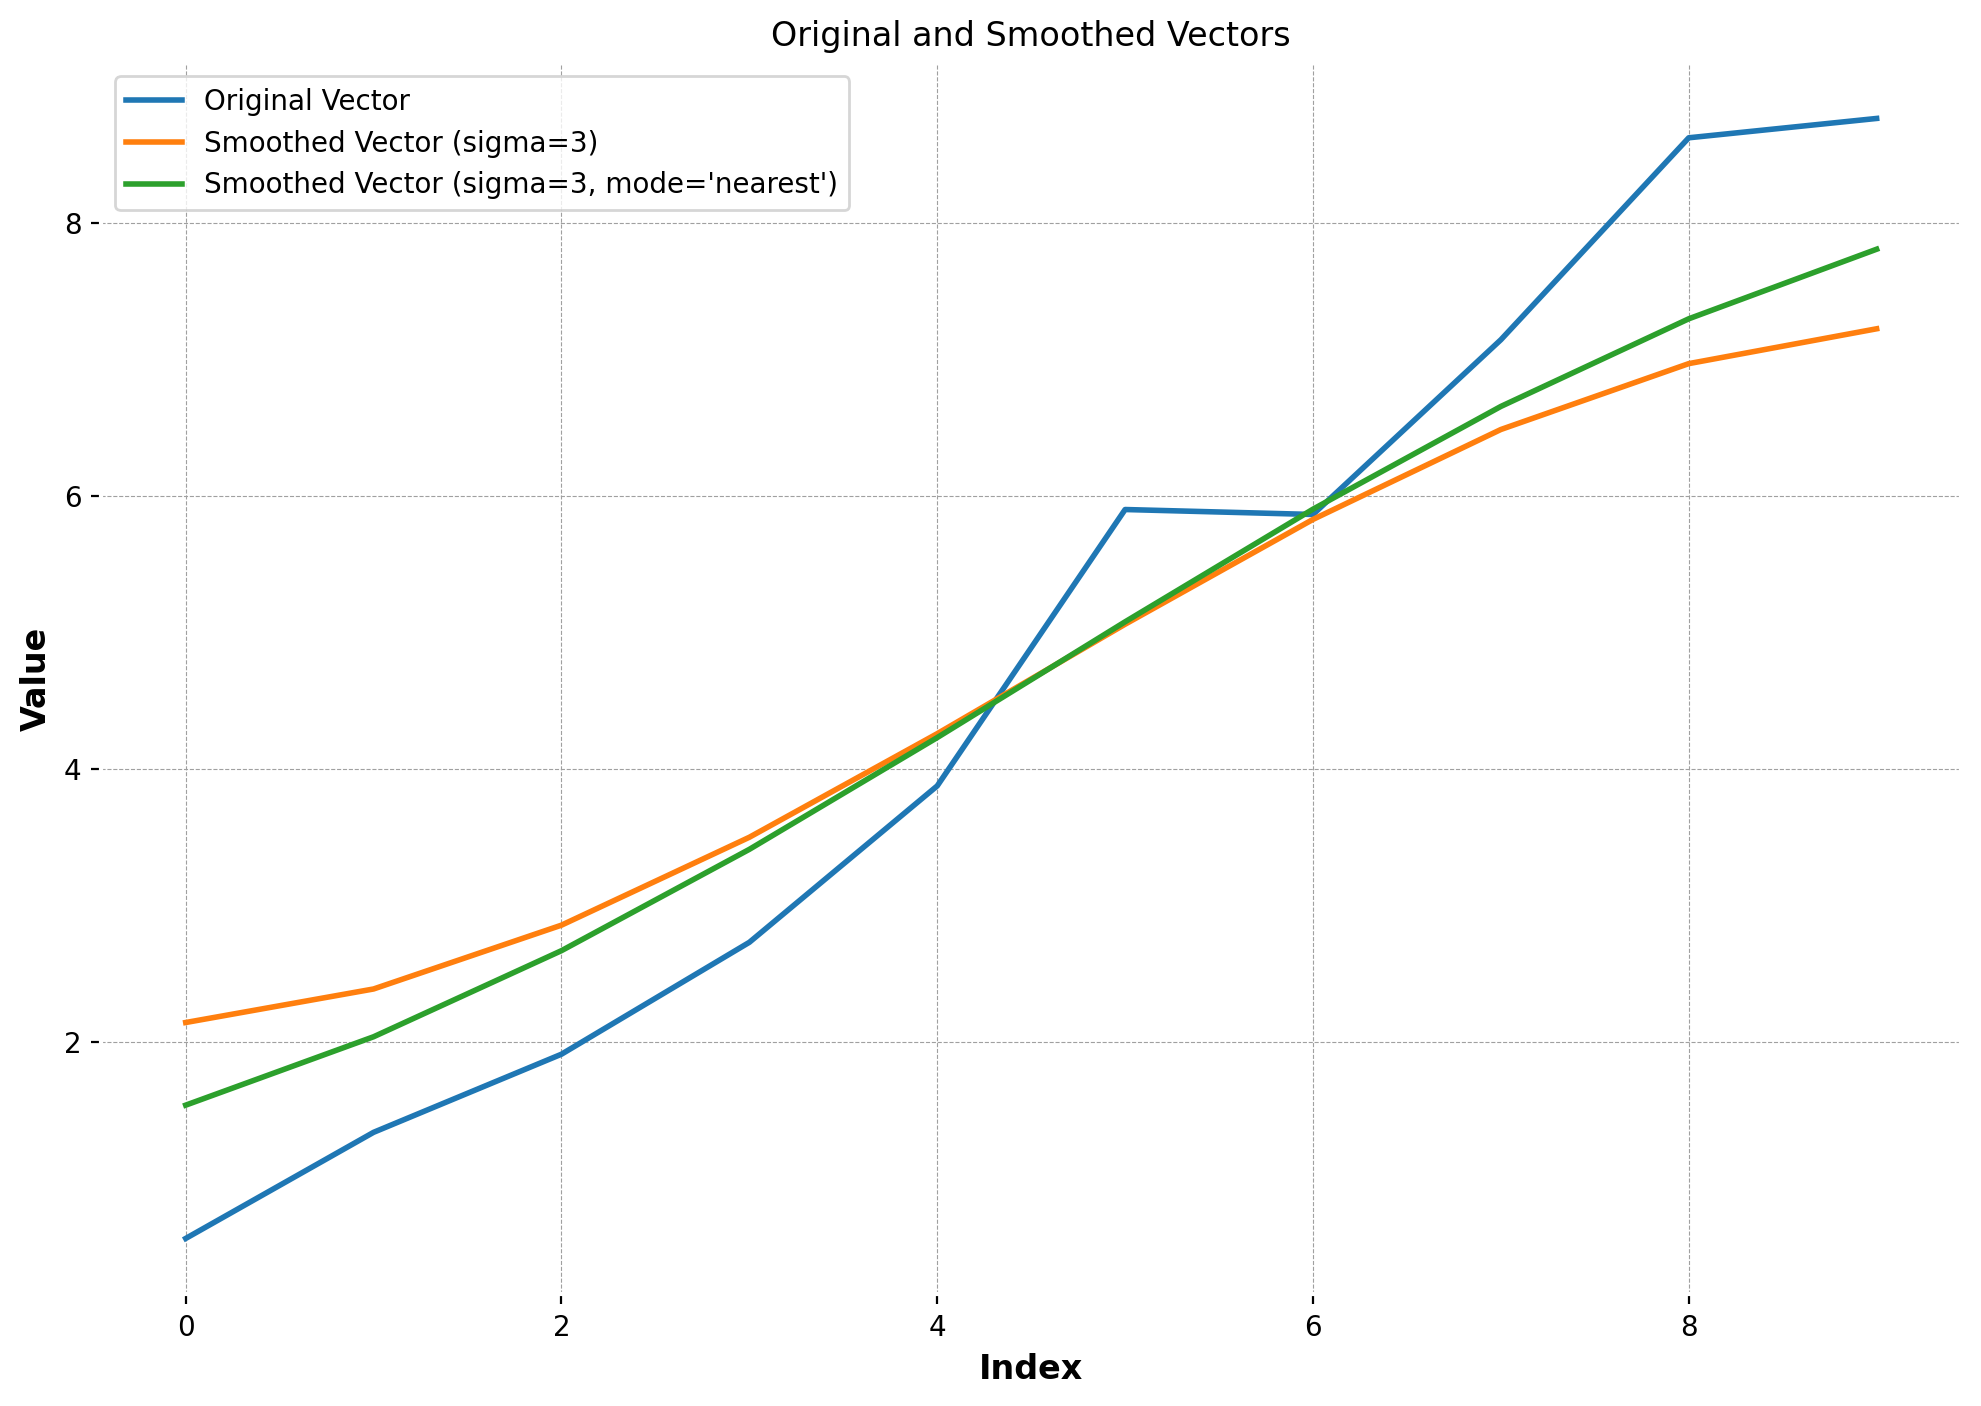

In [58]:
plt.figure(figsize=(12, 8))

plt.plot(vector, label='Original Vector')
# plt.plot(smoothed_vector, label='Smoothed Vector (sigma=1)')
# plt.plot(smoothed_vector_2, label='Smoothed Vector (sigma=2)')
plt.plot(smoothed_vector_3, label='Smoothed Vector (sigma=3)')
# plt.plot(smoothed_vector_n, label="Smoothed Vector (sigma=1, mode='nearest')")
# plt.plot(smoothed_vector_2n, label="Smoothed Vector (sigma=2, mode='nearest')")
plt.plot(smoothed_vector_3n, label="Smoothed Vector (sigma=3, mode='nearest')")

plt.legend()
plt.title('Original and Smoothed Vectors')
plt.xlabel('Index')
plt.ylabel('Value')
plt.grid(True)
plt.show()

In [ ]:
gaussian_filter1d(vector*3.0, sigma=1) / smoothed_vector

In [ ]:
gaussian_filter1d(vector*3.0, sigma=2) / smoothed_vector_2

In [ ]:
sm

In [ ]:
sm/smoothed_vector

In [ ]:
start_time = pd.to_datetime('2024-11-08 09:30:00-05:00')

In [ ]:
def update_plot(start_time):
    end_time = (pd.to_datetime(start_time) + pd.Timedelta(minutes=30))
    # print(f'start_time: {start_time}, end_time: {end_time}')
    m1 = start_time <= bars_df['date']
    m2 = bars_df['date'] <= end_time
    vector = bars_df.loc[m1 & m2, 'close'].values
    x = bars_df.loc[m1 & m2, 'date'].dt.strftime('%H:%M').values

    smoothed_vector = gaussian_filter1d(vector, sigma=1)
    smoothed_vector_2 = gaussian_filter1d(vector, sigma=2)
    smoothed_vector_4_1 = gaussian_filter1d(vector[0:-1], sigma=4)
    smoothed_vector_3 = gaussian_filter1d(vector, sigma=3)
    smoothed_vector_4 = gaussian_filter1d(vector, sigma=4)
    fig, ax = plt.subplots(figsize=(10, 8))  
    plt.plot(x, vector, label='Original Vector')
    plt.plot(x, smoothed_vector_2, label='smoothed_vector_2')
    plt.plot(x[0:-1], smoothed_vector_4_1, label='smoothed_vector_4_1')
    # plt.plot(x, smoothed_vector_3, label='smoothed_vector_3')
    # plt.plot(x, smoothed_vector_4, label='smoothed_vector_4')
    ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
    plt.title('Original Vector')
    plt.legend()

    # plt.subplot(2, 1, 2)
    # plt.plot(smoothed_vector, label='smoothed_vector')
    # plt.plot(smoothed_vector_2, label='smoothed_vector_2')
    # plt.plot(smoothed_vector_3, label='smoothed_vector_3')
    # plt.title('gaussian_filter1d')
    # plt.legend()

    # plt.tight_layout()
    plt.show()




In [ ]:
start_time

In [ ]:
def btn_right_click(obj):
    global start_time
    start_time = start_time + pd.Timedelta(minutes=1)
    update_plot(start_time)
    # print('right click')
    # print(obj)
    # print(event.xdata)
    # print(event.ydata)

def btn_left_click(obj):
    global start_time
    start_time = start_time - pd.Timedelta(minutes=1)
    update_plot(start_time)
    # print('left click')
    # print(obj)
    # print(event.xdata)
    # print(event.ydata)

In [ ]:
# Example vector with noise
start_time = pd.to_datetime('2024-11-08 9:30:00-05:00') # manipulate using slider
end_time = pd.to_datetime('2024-11-08 16:00:00-05:00') # manipulate using slider
start_time_slider = widgets.SelectionSlider(
    options=pd.date_range(start_time, end_time, freq='min'),
    value=start_time, #'2024-11-08 09:30:00',
    description='Start Time',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True
)
widgets.interactive(update_plot, start_time=start_time_slider)


In [ ]:

button_r = widgets.Button(
    description='move right',
    disabled=False,
    button_style='', # 'success', 'info', 'warning', 'danger' or ''
    tooltip='right',
    icon='check' # (FontAwesome names without the `fa-` prefix)
)
button_r.on_click(btn_right_click)
button_l = widgets.Button(
    description='move left',
    disabled=False,
    button_style='', # 'success', 'info', 'warning', 'danger' or ''
    tooltip='left',
    icon='check' # (FontAwesome names without the `fa-` prefix)
)
button_l.on_click(btn_left_click)
# widgets.HBox([button_l, button_r])
# update_plot(start_time)
display(widgets.HBox([button_l, button_r]))


In [ ]:
button_r = widgets.Button(
    description='move right',
    disabled=False,
    button_style='', # 'success', 'info', 'warning', 'danger' or ''
    tooltip='right',
    icon='check' # (FontAwesome names without the `fa-` prefix)
)
button_r.on_click(btn_right_click)
button_l = widgets.Button(
    description='move left',
    disabled=False,
    button_style='', # 'success', 'info', 'warning', 'danger' or ''
    tooltip='left',
    icon='check' # (FontAwesome names without the `fa-` prefix)
)
button_l.on_click(btn_left_click)
widgets.HBox([button_l, button_r])

In [ ]:
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(10, 8))

def animate(i):
    current_time = start_time + pd.Timedelta(minutes=i)
    end_time = current_time + pd.Timedelta(minutes=30)
    m1 = current_time <= bars_df['date']
    m2 = bars_df['date'] <= end_time
    vector = bars_df.loc[m1 & m2, 'close'].values
    x = bars_df.loc[m1 & m2, 'date'].dt.strftime('%H:%M').values

    smoothed_vector_2 = gaussian_filter1d(vector, sigma=2)
    smoothed_vector_3 = gaussian_filter1d(vector, sigma=3)

    ax.clear()
    ax.plot(x, vector, label='Original Vector')
    ax.plot(x, smoothed_vector_2, label='smoothed_vector_2')
    ax.plot(x, smoothed_vector_3, label='smoothed_vector_3')
    ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
    ax.set_title('Original Vector')
    ax.legend()

ani = animation.FuncAnimation(fig, animate, frames=range(0, int((end_time - start_time).total_seconds() / 60)), interval=500)
plt.show()

In [41]:
end_time = (pd.to_datetime(start_time) + pd.Timedelta(minutes=30)) # .strftime('%Y-%m-%d %H:%M:%S')
m1 = start_time <= bars_df['date'] 
m2 = bars_df['date'] <= end_time
vector = bars_df.loc[m1 & m2, 'close'].values

# Apply Gaussian smoothing
smoothed_vector = gaussian_filter1d(vector, sigma=1)
smoothed_vector_2 = gaussian_filter1d(vector, sigma=2)
smoothed_vector_3 = gaussian_filter1d(vector, sigma=3)

import matplotlib.pyplot as plt
# Plot the original vector and the normalized convolution result
plt.figure(figsize=(10, 10))

plt.subplot(2, 1, 1)
plt.plot(vector, label='Original Vector')
plt.plot(smoothed_vector_2, label='smoothed_vector_2')
plt.title('Original Vector')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(smoothed_vector, label='smoothed_vector')
plt.plot(smoothed_vector_2, label='smoothed_vector_2')
plt.plot(smoothed_vector_3, label='smoothed_vector_3')
plt.title('gaussian_filter1d')
plt.legend()

plt.tight_layout()
plt.show()

NameError: name 'start_time' is not defined

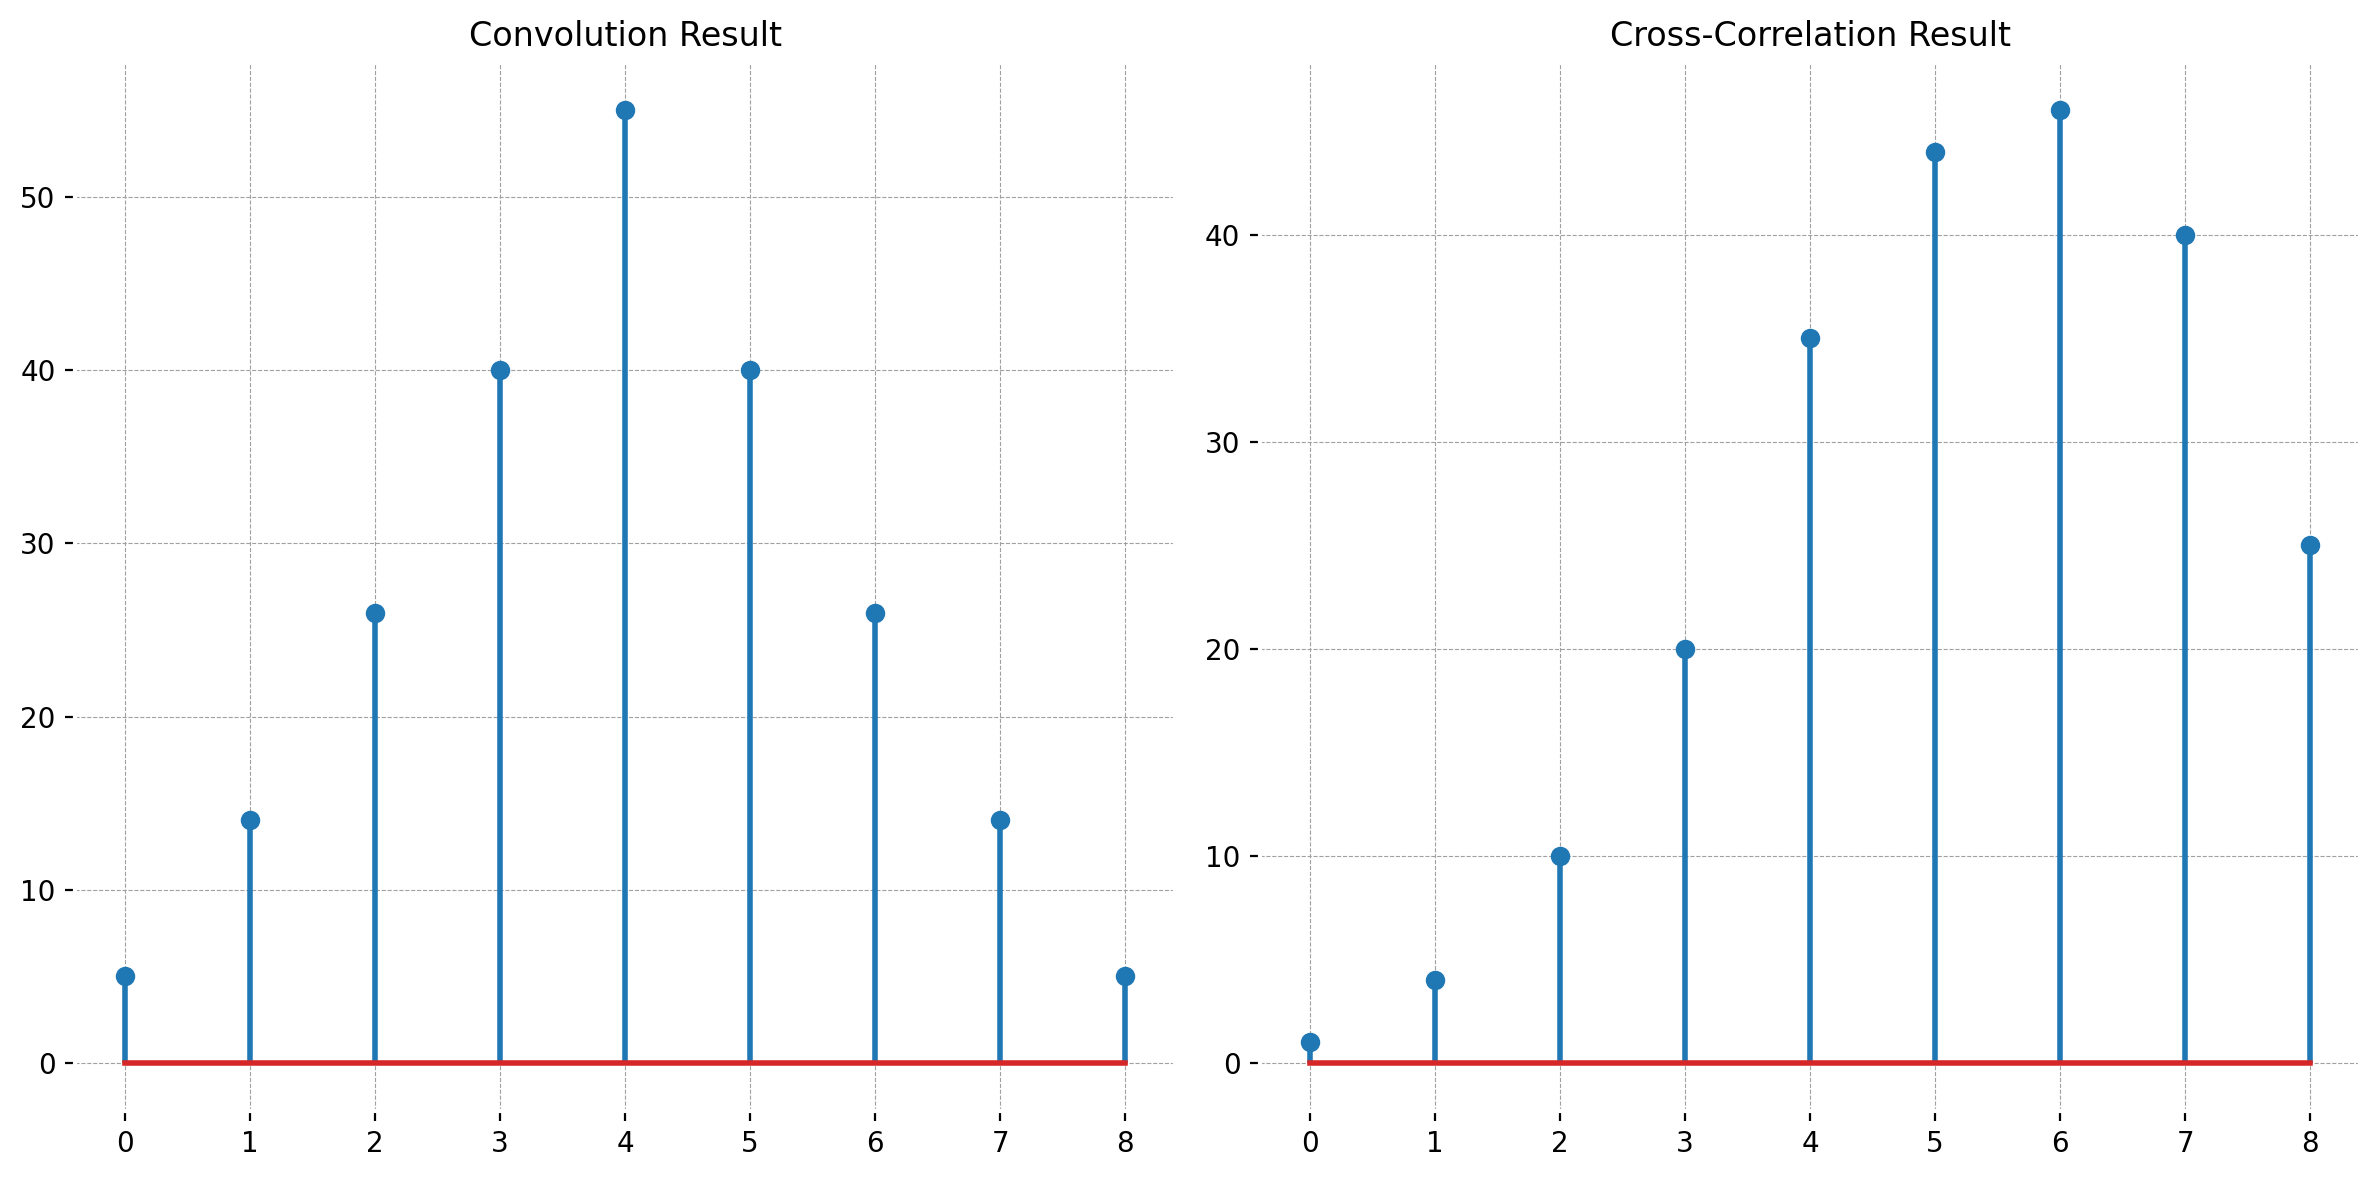

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# Define two sequences
f = np.array([1, 2, 3, 4, 5])
g = np.array([5, 4, 3, 2, 1])

# Convolution
convolution_result = np.convolve(f, g, mode='full')

# Cross-Correlation
cross_correlation_result = np.correlate(f, g, mode='full')

# Plotting the results
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.stem(convolution_result)
plt.title('Convolution Result')

plt.subplot(1, 2, 2)
plt.stem(cross_correlation_result)
plt.title('Cross-Correlation Result')

plt.tight_layout()
plt.show()


In [43]:
# Resample bars into 1-minute intervals
interval = 12  # 12 5-second bars = 1 minute
resampled_bars = []

for i in range(0, len(bars), interval):
    chunk = bars[i:i + interval]
    if not chunk:
        continue
    open_price = chunk[0].open
    high_price = max(bar.high for bar in chunk)
    low_price = min(bar.low for bar in chunk)
    close_price = chunk[-1].close
    volume = sum(bar.volume for bar in chunk)
    average = np.mean([bar.average for bar in chunk])
    bar_count = sum(bar.barCount for bar in chunk)
    resampled_bars.append(BarData(date=chunk[0].date, open=open_price, high=high_price, low=low_price, close=close_price, volume=volume, average=average, barCount=bar_count))

resampled_bars

TypeError: object of type 'NoneType' has no len()

In [ ]:
bars
# Resample bars into 1-minute intervals
interval = 60  # 1 minute in seconds
resampled_bars = []

for i in range(0, len(bars), interval):
    chunk = bars[i:i + interval]
    if not chunk:
        continue
    open_price = chunk[0].open
    high_price = max(bar.high for bar in chunk)
    low_price = min(bar.low for bar in chunk)
    close_price = chunk[-1].close
    volume = sum(bar.volume for bar in chunk)
    average = np.mean([bar.average for bar in chunk])
    bar_count = sum(bar.barCount for bar in chunk)
    resampled_bars.append(BarData(date=chunk[0].date, open=open_price, high=high_price, low=low_price, close=close_price, volume=volume, average=average, barCount=bar_count))

resampled_bars

In [ ]:
hml = [b.high - b.low for b in resampled_bars]
cmo = [b.close - b.open for b in resampled_bars]

In [ ]:
hml

In [ ]:
bars

In [ ]:
np.mean(hml), np.std(hml), np.var(hml), np.median(hml), np.min(hml), np.max(hml)

In [ ]:
mean_hml = np.mean(hml)
std_hml = np.std(hml)
outliers = [x for x in hml if abs(x - mean_hml) > 5 * std_hml]
outliers


In [ ]:
outlier_indices = [i for i, x in enumerate(hml) if abs(x - mean_hml) > 5 * std_hml]
outlier_indices

In [ ]:
np.percentile(hml, 50)

In [ ]:
[len(bars), sys.getsizeof(bars)]

In [ ]:
import ib_insync
ib_insync.ib.install_custom_repr_()

In [ ]:
np.array([ [b.open, b.close] for b in bars[-3:]]).ravel()

Convert the list of bars to a data frame and print the first and last rows:

In [ ]:
df = util.df(bars)

display(df.head())
display(df.tail())

Plot the close data

In [ ]:
df.plot(y='close');

There is also a utility function to plot bars as a candlestick plot. It can accept either a DataFrame or a list of bars. Here it will print the last 100 bars:

In [ ]:
util.barplot(bars[-100:], title=contract.symbol);

## Historical data with realtime updates

A new feature of the API is to get live updates for historical bars. This is done by setting `endDateTime` to an empty string and the `keepUpToDate` parameter to `True`.

Let's get some bars with an keepUpToDate subscription:

In [ ]:
# contract = Forex('EURUSD')
contract = Stock('MSFT', 'SMART', 'USD')


In [ ]:
bars = ib.reqHistoricalData(
        contract,
        endDateTime='',
        durationStr='1 D', # 900 S
        barSizeSetting='1 min', # 5 secs
        whatToShow='TRADES',
        useRTH=False,
        formatDate=1,
        keepUpToDate=True)

In [ ]:
with np.printoptions(precision=2, suppress=True):
    x = np.array([ [b.open, b.high, b.low, b.close, b.volume] for b in bars[-3:]]).ravel()
    print(f"{x}")

In [ ]:
def onBarUpdate(bars, hasNewBar):
    hml = np.array([b.high - b.low for b in bars[-10:]])  # high minus low
    with np.printoptions(precision=2, suppress=True):
        print(hml, hasNewBar)

In [ ]:
bars.updateEvent += onBarUpdate

In [ ]:
bars.updateEvent -= onBarUpdate

In [ ]:
bars1m = []
bars2m = []
bars3m = []


In [ ]:
def onBarUpdate(bars, hasNewBar):
    print(bars[-1], hasNewBar)
    # Resample the incoming bars into 1-minute bars incrementally
    if not hasattr(onBarUpdate, 'temp_bars'):
        onBarUpdate.temp_bars = []
        onBarUpdate.resampled_bars = []

    onBarUpdate.temp_bars.append(bars[-1])

    # if len(onBarUpdate.temp_bars) == interval:
    #     chunk = onBarUpdate.temp_bars
    #     open_price = chunk[0].open
    #     high_price = max(bar.high for bar in chunk)
    #     low_price = min(bar.low for bar in chunk)
    #     close_price = chunk[-1].close
    #     volume = sum(bar.volume for bar in chunk)
    #     average = np.mean([bar.average for bar in chunk])
    #     bar_count = sum(bar.barCount for bar in chunk)
    #     resampled_bar = BarData(date=chunk[0].date, open=open_price, high=high_price, low=low_price, close=close_price, volume=volume, average=average, barCount=bar_count)
    #     onBarUpdate.resampled_bars.append(resampled_bar)
    #     onBarUpdate.temp_bars = []
    #     print(resampled_bar)
    interval = 12  # 12 bars of 5 seconds each make 1 minute
    if len(bars) % interval == 0:
        chunk = bars[-interval:]
        open_price = chunk[0].open
        high_price = max(bar.high for bar in chunk)
        low_price = min(bar.low for bar in chunk)
        close_price = chunk[-1].close
        volume = sum(bar.volume for bar in chunk)
        average = np.mean([bar.average for bar in chunk])
        bar_count = sum(bar.barCount for bar in chunk)
        resampled_bar = BarData(date=chunk[0].date, open=open_price, high=high_price, low=low_price, close=close_price, volume=volume, average=average, barCount=bar_count)
        print(resampled_bar)


In [ ]:
bars.updateEvent -= onBarUpdate

In [ ]:
onBarUpdate.temp_bars

In [ ]:
onBarUpdate.resampled_bars

In [ ]:
len(bars)

In [ ]:
ib.cancelHistoricalData(bars)

In [ ]:
util.logToConsole(logging.DEBUG)

In [ ]:
bars.updateEvent -= onBarUpdate

Replot for every change of the last bar:

In [ ]:
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

def onBarUpdate(bars, hasNewBar):
    print(hasNewBar)
    plt.close()
    plot = util.barplot(bars)
    clear_output(wait=True)
    display(plot)

bars.updateEvent += onBarUpdate

# ib.sleep(100)
# ib.cancelHistoricalData(bars)

Realtime bars
------------------

With ``reqRealTimeBars`` a subscription is started that sends a new bar every 5 seconds.

First we'll set up a event handler for bar updates:

In [ ]:
def onBarUpdate(bars, hasNewBar):
    print(hasNewBar, bars[-1])

Then do the real request and connect the event handler,

In [ ]:
bars = ib.reqRealTimeBars(contract, 60, 'MIDPOINT', True)
# bars.updateEvent += onBarUpdate

let it run for half a minute and then cancel the realtime bars.

In [ ]:
ib.sleep(30)
ib.cancelRealTimeBars(bars)

The advantage of reqRealTimeBars is that it behaves more robust when the connection to the IB server farms is interrupted. After the connection is restored, the bars from during the network outage will be backfilled and the live bars will resume.

reqHistoricalData + keepUpToDate will, at the moment of writing, leave the whole API inoperable after a network interruption.

In [ ]:
ib.disconnect()

In [ ]:
# Convert bars to DataFrame
df_bars = util.df(bars)

# Sort by the "low" column
df_bars_sorted = df_bars.sort_values(by='close')

# Display the sorted DataFrame
display(df_bars_sorted)

In [ ]:
def fmt_elapsed_time(elapsed_time: float) -> str:
    if elapsed_time >= 1:
        s = f"{elapsed_time:.2f} s"
    elif elapsed_time >= 1e-3:
        s = f"{elapsed_time * 1e3:.2f} ms"
    elif elapsed_time >= 1e-6:
        s = f"{elapsed_time * 1e6:.2f} µs"
    else:
        s = f"{elapsed_time * 1e9:.2f} ns"
    return s

# Example usage
elapsed_time = 0.00035004862362757927  # Replace with actual elapsed time
print(fmt_elapsed_time(elapsed_time))

In [ ]:
import numpy as np
from collections import deque

class TimeSeriesStats:
    def __init__(self, window_size):
        self.window_size = window_size
        self.data = deque(maxlen=window_size)
        self.histogram = np.zeros(61)  # Assuming data range is -30 to 30

    def update(self, value):
        if len(self.data) == self.window_size:
            old_value = self.data.popleft()
            self.histogram[int(old_value) + 30] -= 1
        self.data.append(value)
        self.histogram[int(value) + 30] += 1

    def get_range(self):
        return min(self.data), max(self.data)

    def get_quartiles(self):
        sorted_data = sorted(self.data)
        q1 = np.percentile(sorted_data, 25)
        q2 = np.percentile(sorted_data, 50)
        q3 = np.percentile(sorted_data, 75)
        return q1, q2, q3

    def get_deciles(self):
        sorted_data = sorted(self.data)
        return [np.percentile(sorted_data, d) for d in range(10, 100, 10)]

    def is_near_peak_or_valley(self, value):
        peak_threshold = np.percentile(self.data, 90)
        valley_threshold = np.percentile(self.data, 10)
        if value >= peak_threshold:
            return "Near Peak"
        elif value <= valley_threshold:
            return "Near Valley"
        else:
            return "Normal"

# Example usage
window_size = 100  # Adjust the window size as needed
stats = TimeSeriesStats(window_size)

# Simulate streaming data
data_stream = np.random.normal(0, 1, 1000)  # Replace with actual sensor data

for data in data_stream:
    stats.update(data)
    print(f'Current Value: {data}')
    print(f'Range: {stats.get_range()}')
    print(f'Quartiles: {stats.get_quartiles()}')
    print(f'Deciles: {stats.get_deciles()}')
    print(f'Position: {stats.is_near_peak_or_valley(data)}')


In [ ]:
plt.plot(data_stream)
plt.show()